In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
os.chdir('/content/drive/MyDrive/BUDT757/BUDT757 Group 3 Project/')
#

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('Data/enron_spam_data.csv')

In [5]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, average_precision_score, roc_auc_score,
    brier_score_loss
)

def full_report(y_true, y_pred, y_prob, label="Model"):
    """Unified evaluation: accuracy, macro-F1, spam precision/recall, PR-AUC, Brier."""
    print(f"\n=== {label} ===")
    print(f"  Accuracy     : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Macro-F1     : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  Spam Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Spam Recall  : {recall_score(y_true, y_pred):.4f}")
    print(f"  PR-AUC       : {average_precision_score(y_true, y_prob):.4f}")
    print(f"  ROC-AUC      : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Brier Score  : {brier_score_loss(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred, target_names=["ham","spam"]))

Date range

In [ ]:
print("Min Date: ", df['Date'].min())
print("Max Date: ", df['Date'].max())

Min Date:  1999-12-10
Max Date:  2005-09-06


Base line Naive Bayes Split by year

In [6]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    precision_score, recall_score, average_precision_score,
    roc_auc_score, brier_score_loss
)
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ── Clean & prep ──────────────────────────────────────────────────
df = pd.read_csv('Data/enron_spam_data.csv')
df = df.dropna(subset=["Message", "Spam/Ham"])
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["Year"] = df["Date"].dt.year

# Map labels
label_map = {"ham": 0, "spam": 1}
df["label"] = df["Spam/Ham"].map(label_map)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

# Text preprocessing
stop_words = set(stopwords.words("english"))
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["Message"].apply(preprocess_text)

# ── Stratified random split ───────────────────────────────────────
# NOTE: Temporal split is not viable for Enron — the corpus is structured
# so all ham falls in 2000-2002 and all spam in 2003-2005 (a known dataset
# artifact, not real temporal evolution). We use a stratified split for
# in-distribution evaluation and the 2021 corpus for drift/OOD evaluation.
train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    stratify=df["label"]
)

X_train = train_df["clean_text"]
y_train = train_df["label"]
X_test  = test_df["clean_text"]
y_test  = test_df["label"]

# ── Diagnostics ───────────────────────────────────────────────────
print("=== Split Diagnostics ===")
print(f"Train: n={len(train_df):,}, %spam={y_train.mean()*100:.1f}%")
print(f"Test:  n={len(test_df):,},  %spam={y_test.mean()*100:.1f}%")
print("\nYear x class breakdown (for reference):")
print(df.groupby('Year')['label'].agg(['mean','count'])
        .rename(columns={'mean':'%spam','count':'n'}).round(2))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


=== Split Diagnostics ===
Train: n=25,008, %spam=50.5%
Test:  n=8,337,  %spam=50.5%

Year x class breakdown (for reference):
      %spam     n
Year             
1999   0.00   135
2000   0.00  6753
2001   0.01  8387
2002   0.51  2593
2003   1.00   102
2004   1.00  5841
2005   1.00  9534


In [7]:
# ---- Build pipeline ----
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),     # unigrams + bigrams
        min_df=2,
        max_df=0.9
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

# ---- Train ----
nb_model.fit(X_train, y_train)

# ---- Predict ----
nb_proba = nb_model.predict_proba(X_test)[:,1]
nb_pred  = nb_model.predict(X_test)

# ---- Evaluate ----
full_report(y_test, nb_pred, nb_proba, "Naive Bayes (in-distribution)")


=== Naive Bayes (in-distribution) ===
  Accuracy     : 0.9773
  Macro-F1     : 0.9773
  Spam Precision: 0.9725
  Spam Recall  : 0.9829
  PR-AUC       : 0.9962
  ROC-AUC      : 0.9965
  Brier Score  : 0.0198
              precision    recall  f1-score   support

         ham       0.98      0.97      0.98      4124
        spam       0.97      0.98      0.98      4213

    accuracy                           0.98      8337
   macro avg       0.98      0.98      0.98      8337
weighted avg       0.98      0.98      0.98      8337



In [ ]:
def get_nb_model_size(model):
    size = 0
    size += model.class_count_.nbytes
    size += model.class_log_prior_.nbytes
    size += model.feature_count_.nbytes
    size += model.feature_log_prob_.nbytes
    return size / (1024 ** 2)  # MB

print("Naive Bayes parameter memory (MB):", get_nb_model_size(nb_model[1]))

Naive Bayes parameter memory (MB): 0.152618408203125


Now we test against a conceptual drift of spam 2021 emails

In [ ]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 13.3 MB/s eta 0:00:00


In [ ]:
import py7zr

archive_path = "Data/2021.7z"
extract_path = "spam_data_2021"

with py7zr.SevenZipFile(archive_path, mode='r') as z:
    z.extractall(path=extract_path)

print("Extraction complete.")

Extraction complete.


In [ ]:
import os
import pandas as pd

base_path = "spam_data_2021/2021"

rows = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".txt"):
            file_path = os.path.join(root, file)

            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()

            # Extract month from folder name
            month = os.path.basename(root)

            rows.append({
                "month": month,
                "filename": file,
                "text": text
            })



In [ ]:
bruce = pd.DataFrame(rows)

bruce.head()

,month,filename,text
0,01,1610749396.1276270_15.txt,Return-Path: <servicebtc@adn.com>\nDelivered-T...
1,01,1610749396.1276270_17.txt,Return-Path: <gutterprotectorco_promotion-bruc...
2,01,1610749396.1276270_19.txt,Return-Path: <ThreeDimensionalRug-bruce=untrou...
3,01,1610749396.1276270_21.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...
4,01,1610749396.1276270_23.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...


In [ ]:
import email
from email import policy
from email.parser import BytesParser
from email.header import decode_header
from io import BytesIO

In [ ]:
def decode_mime_header(value):
    if not value:
        return None

    decoded_parts = decode_header(value)
    decoded_string = ""

    for part, enc in decoded_parts:
        if isinstance(part, bytes):
            decoded_string += part.decode(enc or "utf-8", errors="ignore")
        else:
            decoded_string += part

    return decoded_string

In [ ]:
import codecs

def safe_decode(payload, charset):
    if not payload:
        return ""

    # Normalize invalid charset values
    if not charset:
        charset = "utf-8"

    try:
        codecs.lookup(charset)
    except LookupError:
        charset = "utf-8"

    return payload.decode(charset, errors="ignore")


def extract_body(msg):
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                payload = part.get_payload(decode=True)
                return safe_decode(payload, part.get_content_charset())

        for part in msg.walk():
            if part.get_content_type() == "text/html":
                payload = part.get_payload(decode=True)
                return safe_decode(payload, part.get_content_charset())
    else:
        payload = msg.get_payload(decode=True)
        return safe_decode(payload, msg.get_content_charset())

In [ ]:
def parse_email(raw_text):
    msg = BytesParser(policy=policy.default).parse(
        BytesIO(raw_text.encode("utf-8", errors="ignore"))
    )

    return pd.Series({
        "message_id": msg.get("Message-ID"),
        "subject": decode_mime_header(msg.get("Subject")),
        "body": extract_body(msg)
    })

parsed = bruce["text"].apply(parse_email)

bruce_w = pd.concat([bruce, parsed], axis=1)

bruce_w.head()

,month,filename,text,message_id,subject,body
0,01,1610749396.1276270_15.txt,Return-Path: <servicebtc@adn.com>\nDelivered-T...,None,Fordert_besseren_Schlaf,"<HTML><HEAD></HEAD>\n<BODY>\n<P><A href=""https..."
1,01,1610749396.1276270_17.txt,Return-Path: <gutterprotectorco_promotion-bruc...,<0.0.0.36.1D6EB7AB70F86EC.58EA18@mail.rwardtv....,Gutter Protector is about to spill their summe...,<html>\n <head> \n <title>unobserved</title> ...
2,01,1610749396.1276270_19.txt,Return-Path: <ThreeDimensionalRug-bruce=untrou...,<73c7fc7b-f6bf-4bd0-8eaf-d8b07fcc881e@unioncas...,Hilarious and eye-catching rug will be the hig...,
3,01,1610749396.1276270_21.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...,<CADmhhyxkxOK-+JF_Sbw=mgLKnxd3ErYAYuL8R2T6KA00...,I Need Your Assistance,Let me start by introducing myself my name is ...
4,01,1610749396.1276270_23.txt,Return-Path: <linux-kernel-owner@vger.kernel.o...,<CAF+m9ZASY+PbDv0Vmx-Y24pwGTCdd6afjQUs7Jkj4GMY...,OK.........................,"Dear Friend,\n\nAn oil business man made a fix..."


In [ ]:
bruce_w.to_csv('bruce_w.csv', index=False)

In [8]:
bruce_w = pd.read_csv('bruce_w.csv')

In [9]:
spam_text = bruce_w['body']

In [10]:
spam_df = pd.DataFrame(
    {"col": [1] * len(spam_text)},
    index=spam_text.index
)

In [11]:
# ── 2021 external (OOD) evaluation ───────────────────────────────
spam_text = spam_text.dropna().reset_index(drop=True)

nb_bruce_pred  = nb_model.predict(spam_text)
nb_bruce_proba = nb_model.predict_proba(spam_text)[:, 1]

# Ground truth: all spam (2021 corpus is spam-only by design)
bruce_true = np.ones(len(nb_bruce_pred), dtype=int)

full_report(bruce_true, nb_bruce_pred, nb_bruce_proba,
            "Naive Bayes (OOD — 2021 spam corpus)")


=== Naive Bayes (OOD — 2021 spam corpus) ===
  Accuracy     : 0.9615
  Macro-F1     : 0.4902
  Spam Precision: 1.0000
  Spam Recall  : 0.9615
  PR-AUC       : 1.0000
  ROC-AUC      : nan
  Brier Score  : 0.0461
              precision    recall  f1-score   support

         ham       0.00      0.00      0.00         0
        spam       1.00      0.96      0.98     18243

    accuracy                           0.96     18243
   macro avg       0.50      0.48      0.49     18243
weighted avg       1.00      0.96      0.98     18243



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zer

# We also test against a temporally the same OOD dataset Spam Assasin, since it has a better class balance

In [12]:
# Load SpamAssassin OOD set
sa_df = pd.read_csv('spamassassin_corpus.csv')
sa_df["clean_text"] = sa_df["message"].apply(preprocess_text)
X_ood = sa_df["clean_text"]
y_ood = sa_df["label"]

nb_ood_pred  = nb_model.predict(X_ood)
nb_ood_proba = nb_model.predict_proba(X_ood)[:, 1]
full_report(y_ood, nb_ood_pred, nb_ood_proba, "Naive Bayes (OOD — SpamAssassin)")


=== Naive Bayes (OOD — SpamAssassin) ===
  Accuracy     : 0.4974
  Macro-F1     : 0.4771
  Spam Precision: 0.4114
  Spam Recall  : 0.9837
  PR-AUC       : 0.8307
  ROC-AUC      : 0.9028
  Brier Score  : 0.3595
              precision    recall  f1-score   support

         ham       0.96      0.23      0.37      6951
        spam       0.41      0.98      0.58      3793

    accuracy                           0.50     10744
   macro avg       0.69      0.61      0.48     10744
weighted avg       0.77      0.50      0.45     10744



# Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ))
])

In [15]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=2,
                                 ngram_range=(1, 2))),
                ('lr',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [16]:
lr_clean_pred = lr_model.predict(X_test)
lr_clean_proba = lr_model.predict_proba(X_test)[:, 1]

full_report(y_test, lr_clean_pred, lr_clean_proba, "Linear Regression (in-distribution)")


=== Linear Regression (in-distribution) ===
  Accuracy     : 0.9815
  Macro-F1     : 0.9815
  Spam Precision: 0.9716
  Spam Recall  : 0.9924
  PR-AUC       : 0.9978
  ROC-AUC      : 0.9981
  Brier Score  : 0.0180
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98      4124
        spam       0.97      0.99      0.98      4213

    accuracy                           0.98      8337
   macro avg       0.98      0.98      0.98      8337
weighted avg       0.98      0.98      0.98      8337



In [17]:
bruce_lr_proba = lr_model.predict_proba(spam_text)[:,1]
bruce_lr_pred = lr_model.predict(spam_text)

In [18]:
full_report(bruce_true, bruce_lr_pred, bruce_lr_proba, "Linear Regression (OOD - 2021)")



=== Linear Regression (OOD - 2021) ===
  Accuracy     : 0.9756
  Macro-F1     : 0.4938
  Spam Precision: 1.0000
  Spam Recall  : 0.9756
  PR-AUC       : 1.0000
  ROC-AUC      : nan
  Brier Score  : 0.0337
              precision    recall  f1-score   support

         ham       0.00      0.00      0.00         0
        spam       1.00      0.98      0.99     18243

    accuracy                           0.98     18243
   macro avg       0.50      0.49      0.49     18243
weighted avg       1.00      0.98      0.99     18243



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zer

In [ ]:
lr_ood_pred  = lr_model.predict(X_ood)
lr_ood_proba = lr_model.predict_proba(X_ood)[:, 1]
full_report(y_ood, lr_ood_pred, lr_ood_proba, "Linear Regression (OOD — SpamAssassin)")


=== Linear Regression (OOD — SpamAssassin) ===
  Accuracy     : 0.8493
  Macro-F1     : 0.8227
  Spam Precision: 0.8899
  Spam Recall  : 0.6541
  PR-AUC       : 0.8742
  ROC-AUC      : 0.8998
  Brier Score  : 0.1129
              precision    recall  f1-score   support

         ham       0.84      0.96      0.89      6951
        spam       0.89      0.65      0.75      3793

    accuracy                           0.85     10744
   macro avg       0.86      0.80      0.82     10744
weighted avg       0.85      0.85      0.84     10744



In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Character n-gram robustness baseline ──────────────────────────────
char_ngram_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer='char_wb',   # character n-grams within word boundaries
        ngram_range=(3, 5),
        max_features=50000,
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("lr", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42))
])

char_ngram_model.fit(X_train, y_train)

cn_pred  = char_ngram_model.predict(X_test)
cn_proba = char_ngram_model.predict_proba(X_test)[:,1]
full_report(y_test, cn_pred, cn_proba, "Char N-gram LR (robustness baseline)")


=== Char N-gram LR (robustness baseline) ===
  Accuracy     : 0.9832
  Macro-F1     : 0.9832
  Spam Precision: 0.9731
  Spam Recall  : 0.9943
  PR-AUC       : 0.9988
  ROC-AUC      : 0.9987
  Brier Score  : 0.0164
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98      4124
        spam       0.97      0.99      0.98      4213

    accuracy                           0.98      8337
   macro avg       0.98      0.98      0.98      8337
weighted avg       0.98      0.98      0.98      8337



In [ ]:
bruce_cn_pred  = char_ngram_model.predict(spam_text)
bruce_cn_proba = char_ngram_model.predict_proba(spam_text)[:,1]
full_report(bruce_true, bruce_cn_pred, bruce_cn_proba, "Char N-gram LR (OOD - 2021)")



=== Char N-gram LR (OOD - 2021) ===
  Accuracy     : 0.9867
  Macro-F1     : 0.4967
  Spam Precision: 1.0000
  Spam Recall  : 0.9867
  PR-AUC       : 1.0000
  ROC-AUC      : nan
  Brier Score  : 0.0261
              precision    recall  f1-score   support

         ham       0.00      0.00      0.00         0
        spam       1.00      0.99      0.99     18243

    accuracy                           0.99     18243
   macro avg       0.50      0.49      0.50     18243
weighted avg       1.00      0.99      0.99     18243



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zer

In [ ]:
cn_ood_pred  = char_ngram_model.predict(X_ood)
cn_ood_proba = char_ngram_model.predict_proba(X_ood)[:, 1]
full_report(y_ood, cn_ood_pred, cn_ood_proba, "Character n-gram (OOD — SpamAssassin)")


=== Character n-gram (OOD — SpamAssassin) ===
  Accuracy     : 0.4026
  Macro-F1     : 0.3434
  Spam Precision: 0.3711
  Spam Recall  : 0.9958
  PR-AUC       : 0.8865
  ROC-AUC      : 0.9148
  Brier Score  : 0.3831
              precision    recall  f1-score   support

         ham       0.97      0.08      0.15      6951
        spam       0.37      1.00      0.54      3793

    accuracy                           0.40     10744
   macro avg       0.67      0.54      0.34     10744
weighted avg       0.76      0.40      0.29     10744



# DistilBert

In [20]:
!pip install transformers datasets accelerate evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [21]:
import torch
import numpy as np
import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [22]:
from datasets import Dataset
train_dataset = Dataset.from_pandas(train_df[["Message", "label"]])
test_dataset  = Dataset.from_pandas(test_df[["Message", "label"]])

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["Message"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/25008 [00:00<?, ? examples/s]

Map:   0%|          | 0/8337 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": (predictions == labels).mean()
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,  # Start small
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    seed=42
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.035582,0.032842,0.990644
2,0.029277,0.028580,0.994482


TrainOutput(global_step=3126, training_loss=0.04082796671436724, metrics={'train_runtime': 1334.567, 'train_samples_per_second': 37.477, 'train_steps_per_second': 2.342, 'total_flos': 3312744705589248.0, 'train_loss': 0.04082796671436724, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.02857968397438526, 'eval_accuracy': 0.994482427731798, 'eval_runtime': 63.1772, 'eval_samples_per_second': 131.962, 'eval_steps_per_second': 8.262, 'epoch': 2.0}


In [ ]:
print("GPU memory allocated:",
      torch.cuda.memory_allocated() / 1024**3, "GB")

GPU memory allocated: 0.7882428169250488 GB


In [ ]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# Save model and tokenizer
model.save_pretrained("bert_spam_model_2")
tokenizer.save_pretrained("bert_spam_model_2")

In [25]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert_spam_model_2")
tokenizer = AutoTokenizer.from_pretrained("bert_spam_model_2")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [26]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import torch
from sklearn.metrics import accuracy_score

def get_bert_preds_and_probs(texts, model, tokenizer, device, batch_size=32):
    """Returns (predictions, spam_probabilities) for a list of texts."""
    all_preds  = []
    all_probs  = []
    model.eval()

    texts_clean = [str(t)[:512] for t in texts if pd.notna(t)]

    for i in range(0, len(texts_clean), batch_size):
        batch = texts_clean[i:i+batch_size]
        encodings = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**encodings)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # spam probability

    return np.array(all_preds), np.array(all_probs)


# ── 1. Enron test (in-distribution) ──────────────────────────────
bert_enron_pred, bert_enron_proba = get_bert_preds_and_probs(
    X_test.tolist(), model, tokenizer, device
)
full_report(y_test, bert_enron_pred, bert_enron_proba,
            "DistilBERT (in-distribution — Enron test)")


# ── 2. SpamAssassin (OOD — domain shift) ─────────────────────────
sa_texts = sa_df["message"].fillna("").tolist()
bert_sa_pred, bert_sa_proba = get_bert_preds_and_probs(
    sa_texts, model, tokenizer, device
)
full_report(y_ood, bert_sa_pred, bert_sa_proba,
            "DistilBERT (OOD — SpamAssassin)")


# ── 3. Bruce 2021 (drift corpus — spam only, no full_report) ─────
# NOTE: Bruce is spam-only by design. full_report() is not used here
# because ham metrics are undefined. We report spam detection rate
# and mean confidence only, as this corpus is used for drift detection
# (RQ3), not balanced classification evaluation.
bruce_texts = spam_text.dropna().astype(str).tolist()
bert_bruce_pred, bert_bruce_proba = get_bert_preds_and_probs(
    bruce_texts, model, tokenizer, device
)
bruce_true = np.ones(len(bert_bruce_pred), dtype=int)

print("\n" + "="*50)
print("  DistilBERT (Bruce 2021 — drift corpus, spam-only)")
print("="*50)
print(f"  Total emails     : {len(bert_bruce_pred):,}")
print(f"  Detected as spam : {bert_bruce_pred.sum():,} ({bert_bruce_pred.mean()*100:.1f}%)")
print(f"  Mean spam prob   : {bert_bruce_proba.mean():.4f}")
print(f"  Brier (vs spam)  : {brier_score_loss(bruce_true, bert_bruce_proba):.4f}")
print("  NOTE: Macro-F1/ham metrics undefined — corpus is spam-only.")
print("        Use these results for drift analysis only (RQ3).")


=== DistilBERT (in-distribution — Enron test) ===
  Accuracy     : 0.8997
  Macro-F1     : 0.8986
  Spam Precision: 0.8364
  Spam Recall  : 0.9964
  PR-AUC       : 0.9905
  ROC-AUC      : 0.9914
  Brier Score  : 0.0948
              precision    recall  f1-score   support

         ham       1.00      0.80      0.89      4124
        spam       0.84      1.00      0.91      4213

    accuracy                           0.90      8337
   macro avg       0.92      0.90      0.90      8337
weighted avg       0.92      0.90      0.90      8337


=== DistilBERT (OOD — SpamAssassin) ===
  Accuracy     : 0.6287
  Macro-F1     : 0.6278
  Spam Precision: 0.4869
  Spam Recall  : 0.9612
  PR-AUC       : 0.8087
  ROC-AUC      : 0.8786
  Brier Score  : 0.3506
              precision    recall  f1-score   support

         ham       0.95      0.45      0.61      6951
        spam       0.49      0.96      0.65      3793

    accuracy                           0.63     10744
   macro avg       0.72  

# Evasion

In [55]:
import random
import re

def misspell_attack(text):
    replacements = {
        "free": "fr33",
        "click": "cl1ck",
        "offer": "0ffer",
        "money": "m0ney",
        "win": "w1n"
    }
    for k, v in replacements.items():
        text = re.sub(rf"\b{k}\b", v, text, flags=re.IGNORECASE)
    return text


def case_attack(text):
    return "".join(
        c.upper() if random.random() > 0.5 else c.lower()
        for c in text
    )


def padding_attack(text):
    padding = " meeting schedule project discussion quarterly analysis update"
    return text + padding


def special_char_attack(text):
    return re.sub(r"[aeiou]", lambda m: m.group(0) + "!", text)

In [56]:
subset_size = 1000

test_subset = test_df.sample(subset_size, random_state=42).copy()

attacks = {
    "clean": lambda x: x,
    "misspell": misspell_attack,
    "case": case_attack,
    "padding": padding_attack,
    "special_char": special_char_attack
}

attacked_sets = {}

for name, attack_fn in attacks.items():
    attacked_sets[name] = test_subset["Message"].apply(attack_fn)

sa_subset = sa_df.sample(1000, random_state=42).copy()
sa_attacked_sets = {}
for name, attack_fn in attacks.items():
    sa_attacked_sets[name] = sa_subset["clean_text"].apply(attack_fn)

Enron Attacks

In [57]:
nb_results = {}

for name, texts in attacked_sets.items():
    preds = nb_model.predict(texts)
    probs = nb_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    nb_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

nb_results

{'clean': {'accuracy': 0.979,
  'f1': 0.9797492767598843,
  'confidence': np.float64(0.9603894853144959)},
 'misspell': {'accuracy': 0.978,
  'f1': 0.9787644787644788,
  'confidence': np.float64(0.9594962061018569)},
 'case': {'accuracy': 0.979,
  'f1': 0.9797492767598843,
  'confidence': np.float64(0.9603894853144959)},
 'padding': {'accuracy': 0.895,
  'f1': 0.8881789137380192,
  'confidence': np.float64(0.9462977259379586)},
 'special_char': {'accuracy': 0.531,
  'f1': 0.6875416389073951,
  'confidence': np.float64(0.9847946174580525)}}

In [58]:
lr_results = {}

for name, texts in attacked_sets.items():
    preds = lr_model.predict(texts)
    probs = lr_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    lr_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

lr_results

{'clean': {'accuracy': 0.985,
  'f1': 0.9855907780979827,
  'confidence': np.float64(0.936414159170899)},
 'misspell': {'accuracy': 0.985,
  'f1': 0.9855907780979827,
  'confidence': np.float64(0.9335935468255852)},
 'case': {'accuracy': 0.985,
  'f1': 0.9855907780979827,
  'confidence': np.float64(0.936414159170899)},
 'padding': {'accuracy': 0.927,
  'f1': 0.9238790406673618,
  'confidence': np.float64(0.9074585498271079)},
 'special_char': {'accuracy': 0.527,
  'f1': 0.6857142857142857,
  'confidence': np.float64(0.9527380886135206)}}

In [59]:
char_results = {}

for name, texts in attacked_sets.items():
    preds = char_ngram_model.predict(texts)
    probs = char_ngram_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    char_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

char_results

{'clean': {'accuracy': 0.972,
  'f1': 0.9734848484848485,
  'confidence': np.float64(0.9243159142504833)},
 'misspell': {'accuracy': 0.974,
  'f1': 0.9753320683111955,
  'confidence': np.float64(0.9238717092122228)},
 'case': {'accuracy': 0.972,
  'f1': 0.9734848484848485,
  'confidence': np.float64(0.9243135834281762)},
 'padding': {'accuracy': 0.922,
  'f1': 0.91875,
  'confidence': np.float64(0.9015268173916092)},
 'special_char': {'accuracy': 0.824,
  'f1': 0.8538205980066446,
  'confidence': np.float64(0.7863998497679529)}}

In [60]:
import torch
import numpy as np

def evaluate_bert(texts):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

    preds = torch.argmax(probs, dim=1).cpu().numpy()
    confidence = probs.max(dim=1).values.mean().item()

    return preds, confidence

In [61]:
bert_results = {}

for name, texts in attacked_sets.items():
    preds, confidence = evaluate_bert(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)

    bert_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

bert_results

{'clean': {'accuracy': 0.994,
  'f1': 0.9941972920696325,
  'confidence': 0.9989741444587708},
 'misspell': {'accuracy': 0.994,
  'f1': 0.9941972920696325,
  'confidence': 0.9989662170410156},
 'case': {'accuracy': 0.994,
  'f1': 0.9941972920696325,
  'confidence': 0.9989742040634155},
 'padding': {'accuracy': 0.982,
  'f1': 0.9823182711198428,
  'confidence': 0.9982701539993286},
 'special_char': {'accuracy': 0.657,
  'f1': 0.7501820830298617,
  'confidence': 0.992801308631897}}

Spam Assasin

In [73]:
sa_nb_results = {}

for name, texts in sa_attacked_sets.items():
    preds = nb_model.predict(texts)
    probs = nb_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    sa_nb_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

sa_nb_results

{'clean': {'accuracy': 0.496,
  'f1': 0.6294117647058823,
  'confidence': np.float64(0.8480310255802578)},
 'misspell': {'accuracy': 0.497,
  'f1': 0.6293294030950627,
  'confidence': np.float64(0.8462802448180228)},
 'case': {'accuracy': 0.496,
  'f1': 0.6294117647058823,
  'confidence': np.float64(0.8480310255802578)},
 'padding': {'accuracy': 0.486,
  'f1': 0.5284403669724771,
  'confidence': np.float64(0.8573261880502557)},
 'special_char': {'accuracy': 0.516,
  'f1': 0.6807387862796834,
  'confidence': np.float64(0.9895749193129815)}}

In [74]:
sa_lr_results = {}

for name, texts in sa_attacked_sets.items():
    preds = lr_model.predict(texts)
    probs = lr_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    sa_lr_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

sa_lr_results

{'clean': {'accuracy': 0.48,
  'f1': 0.6136701337295691,
  'confidence': np.float64(0.7881470700347556)},
 'misspell': {'accuracy': 0.479,
  'f1': 0.6109036594473488,
  'confidence': np.float64(0.7812204555055432)},
 'case': {'accuracy': 0.48,
  'f1': 0.6136701337295691,
  'confidence': np.float64(0.7881470700347556)},
 'padding': {'accuracy': 0.482,
  'f1': 0.5203703703703704,
  'confidence': np.float64(0.7828749768045079)},
 'special_char': {'accuracy': 0.516,
  'f1': 0.6807387862796834,
  'confidence': np.float64(0.959030947481886)}}

In [75]:
sa_char_results = {}

for name, texts in sa_attacked_sets.items():
    preds = char_ngram_model.predict(texts)
    probs = char_ngram_model.predict_proba(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)
    confidence = probs.max(axis=1).mean()

    sa_char_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

sa_char_results

{'clean': {'accuracy': 0.505,
  'f1': 0.6616541353383458,
  'confidence': np.float64(0.8360816924947513)},
 'misspell': {'accuracy': 0.507,
  'f1': 0.6625598904859685,
  'confidence': np.float64(0.8322479751916776)},
 'case': {'accuracy': 0.505,
  'f1': 0.6616541353383458,
  'confidence': np.float64(0.8360817745953434)},
 'padding': {'accuracy': 0.486,
  'f1': 0.5344202898550725,
  'confidence': np.float64(0.7698544531573737)},
 'special_char': {'accuracy': 0.514,
  'f1': 0.678996036988111,
  'confidence': np.float64(0.8694582465403855)}}

In [76]:
sa_bert_results = {}

for name, texts in sa_attacked_sets.items():
    preds, confidence = evaluate_bert(texts)

    acc = accuracy_score(test_subset["label"], preds)
    f1 = f1_score(test_subset["label"], preds)

    sa_bert_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "confidence": confidence
    }

sa_bert_results

{'clean': {'accuracy': 0.513,
  'f1': 0.6781229345670853,
  'confidence': 0.999385416507721},
 'misspell': {'accuracy': 0.513,
  'f1': 0.6781229345670853,
  'confidence': 0.999413013458252},
 'case': {'accuracy': 0.513,
  'f1': 0.6781229345670853,
  'confidence': 0.999385416507721},
 'padding': {'accuracy': 0.508,
  'f1': 0.671562082777036,
  'confidence': 0.9984510540962219},
 'special_char': {'accuracy': 0.516,
  'f1': 0.6807387862796834,
  'confidence': 0.9995812177658081}}

In [66]:
def build_comparison_table(nb_results, lr_results, char_results, bert_results):
    rows = []
    for attack in nb_results:
        rows.append({
            "Attack"        : attack,
            "NB Acc"        : nb_results[attack]["accuracy"],
            "LR Acc"        : lr_results[attack]["accuracy"],
            "CharNgram Acc" : char_results[attack]["accuracy"],
            "BERT Acc"      : bert_results[attack]["accuracy"],
            "NB Macro-F1"   : nb_results[attack].get("macro_f1", "—"),
            "LR Macro-F1"   : lr_results[attack].get("macro_f1", "—"),
            "CharNgram Macro-F1"   : char_results[attack].get("macro_f1", "—"),
            "BERT Macro-F1" : bert_results[attack].get("macro_f1", "—"),
        })
    df_out = pd.DataFrame(rows).set_index("Attack")
    # Degradation from clean baseline
    for col in ["NB Acc","LR Acc","CharNgram Acc","BERT Acc"]:
        df_out[col.replace("Acc","Δ")] = df_out[col] - df_out.loc["clean", col]
    return df_out

In [68]:
comparison_table = build_comparison_table(nb_results, lr_results, char_results, bert_results)
print(" === Enron Adversarial ===")
print(comparison_table.round(4))

 === Enron Adversarial ===
              NB Acc  LR Acc  CharNgram Acc  BERT Acc NB Macro-F1 LR Macro-F1  \
Attack                                                                          
clean          0.979   0.985          0.972     0.994           —           —   
misspell       0.978   0.985          0.974     0.994           —           —   
case           0.979   0.985          0.972     0.994           —           —   
padding        0.895   0.927          0.922     0.982           —           —   
special_char   0.531   0.527          0.824     0.657           —           —   

             CharNgram Macro-F1 BERT Macro-F1   NB Δ   LR Δ  CharNgram Δ  \
Attack                                                                     
clean                         —             —  0.000  0.000        0.000   
misspell                      —             — -0.001  0.000        0.002   
case                          —             —  0.000  0.000        0.000   
padding                  

In [77]:
comparison_table = build_comparison_table(sa_nb_results, sa_lr_results, sa_char_results, sa_bert_results)
print(" === Spam Assasin Adversarial ===")
print(comparison_table.round(4))

 === Spam Assasin Adversarial ===
              NB Acc  LR Acc  CharNgram Acc  BERT Acc NB Macro-F1 LR Macro-F1  \
Attack                                                                          
clean          0.496   0.480          0.505     0.513           —           —   
misspell       0.497   0.479          0.507     0.513           —           —   
case           0.496   0.480          0.505     0.513           —           —   
padding        0.486   0.482          0.486     0.508           —           —   
special_char   0.516   0.516          0.514     0.516           —           —   

             CharNgram Macro-F1 BERT Macro-F1   NB Δ   LR Δ  CharNgram Δ  \
Attack                                                                     
clean                         —             —  0.000  0.000        0.000   
misspell                      —             —  0.001 -0.001        0.002   
case                          —             —  0.000  0.000        0.000   
padding           

In [71]:
clean_nb = nb_results["clean"]["accuracy"]
clean_bert = bert_results["clean"]["accuracy"]
clean_logit = lr_results["clean"]["accuracy"]
clean_ngram = char_results["clean"]["accuracy"]
for attack in nb_results:
    print("Attack:", attack)
    print("NB Δ:", clean_nb - nb_results[attack]["accuracy"])
    print("NGRAM Δ:", clean_ngram - char_results[attack]["accuracy"])
    print("BERT Δ:", clean_bert - bert_results[attack]["accuracy"])
    print("LR Δ:", clean_logit - lr_results[attack]["accuracy"])
    print()

Attack: clean
NB Δ: 0.0
NGRAM Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: misspell
NB Δ: 0.0010000000000000009
NGRAM Δ: -0.0020000000000000018
BERT Δ: 0.0
LR Δ: 0.0

Attack: case
NB Δ: 0.0
NGRAM Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: padding
NB Δ: 0.08399999999999996
NGRAM Δ: 0.04999999999999993
BERT Δ: 0.01200000000000001
LR Δ: 0.05799999999999994

Attack: special_char
NB Δ: 0.44799999999999995
NGRAM Δ: 0.14800000000000002
BERT Δ: 0.33699999999999997
LR Δ: 0.45799999999999996



In [78]:
sa_clean_nb = sa_nb_results["clean"]["accuracy"]
sa_clean_bert = sa_bert_results["clean"]["accuracy"]
sa_clean_logit = sa_lr_results["clean"]["accuracy"]
sa_clean_ngram = sa_char_results["clean"]["accuracy"]
for attack in nb_results:
    print("Attack:", attack)
    print("NB Δ:", sa_clean_nb - sa_nb_results[attack]["accuracy"])
    print("NGRAM Δ:", sa_clean_ngram - sa_char_results[attack]["accuracy"])
    print("BERT Δ:", sa_clean_bert - sa_bert_results[attack]["accuracy"])
    print("LR Δ:", sa_clean_logit - sa_lr_results[attack]["accuracy"])
    print()

Attack: clean
NB Δ: 0.0
NGRAM Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: misspell
NB Δ: -0.0010000000000000009
NGRAM Δ: -0.0020000000000000018
BERT Δ: 0.0
LR Δ: 0.0010000000000000009

Attack: case
NB Δ: 0.0
NGRAM Δ: 0.0
BERT Δ: 0.0
LR Δ: 0.0

Attack: padding
NB Δ: 0.010000000000000009
NGRAM Δ: 0.019000000000000017
BERT Δ: 0.0050000000000000044
LR Δ: -0.0020000000000000018

Attack: special_char
NB Δ: -0.020000000000000018
NGRAM Δ: -0.009000000000000008
BERT Δ: -0.0030000000000000027
LR Δ: -0.03600000000000003



# Confidence Shift with concept drift

#### Naive Bayes

In [24]:
# Validation predictions
nb_enron_proba = nb_model.predict_proba(X_test)
nb_enron_conf = nb_enron_proba.max(axis=1)

# Test predictions
nb_ood_proba = nb_model.predict_proba(X_ood)
nb_ood_conf = nb_ood_proba.max(axis=1)

print("Validation mean confidence:", nb_enron_conf.mean())
print("Test mean confidence:", nb_ood_conf.mean())
print("Confidence shift:", nb_ood_conf.mean() - nb_enron_conf.mean())

Validation mean confidence: 0.9617657883162792
Test mean confidence: 0.8455503891664874
Confidence shift: -0.11621539914979184


In [32]:
import numpy as np

def summarize_conf(conf):
    return {
        "mean": np.mean(conf),
        "std": np.std(conf),
        "min": np.min(conf),
        "25%": np.percentile(conf, 25),
        "50%": np.median(conf),
        "75%": np.percentile(conf, 75),
        "max": np.max(conf),
    }

print("Enron confidence stats:", summarize_conf(nb_enron_conf))
print("Spam Assasin confidence stats:", summarize_conf(nb_ood_conf))

Enron confidence stats: {'mean': np.float64(0.9617657883162792), 'std': np.float64(0.08998119873152355), 'min': np.float64(0.5028966590253691), '25%': np.float64(0.9774596746288303), '50%': np.float64(0.9980913878390815), '75%': np.float64(0.9999417888594688), 'max': np.float64(0.9999999999794227)}
Spam Assasin confidence stats: {'mean': np.float64(0.8455503891664874), 'std': np.float64(0.15757549765252124), 'min': np.float64(0.5003203575124568), '25%': np.float64(0.7238716754328695), '50%': np.float64(0.9007740606630372), '75%': np.float64(0.9911928034822974), 'max': np.float64(0.9999997040153528)}


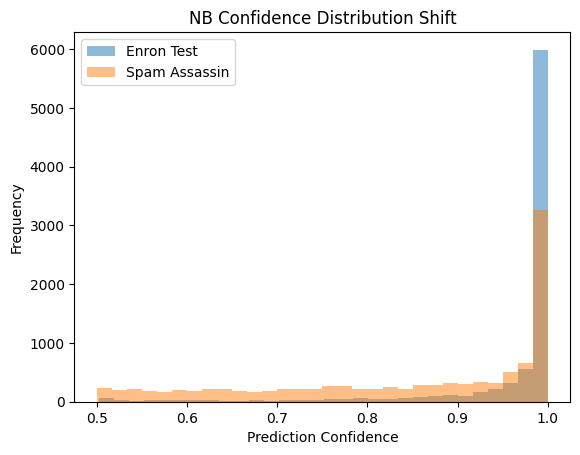

In [33]:
import matplotlib.pyplot as plt
plt.cla()
plt.hist(nb_enron_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(nb_ood_conf, bins=30, alpha=0.5, label="Spam Assassin")
plt.legend()
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("NB Confidence Distribution Shift")
plt.show()

In [45]:
from sklearn.metrics import brier_score_loss

nb_enron_brier = brier_score_loss(y_test, nb_enron_proba[:,1])
nb_ood_brier = brier_score_loss(y_ood, nb_ood_proba[:,1])

print("Enron Brier:", nb_enron_brier)
print("Spam Assasin Brier:", nb_ood_brier)

Enron Brier: 0.019751676293967763
Spam Assasin Brier: 0.35946905762969583


#### Logistic Regression

In [29]:
# Validation predictions
lr_enron_proba = lr_model.predict_proba(X_test)
lr_enron_conf = lr_enron_proba.max(axis=1)

# Test predictions
lr_ood_proba = lr_model.predict_proba(X_ood)
lr_ood_conf = lr_ood_proba.max(axis=1)

print("Enron mean confidence:", lr_enron_conf.mean())
print("Spam Assasin mean confidence:", lr_ood_conf.mean())
print("Confidence shift:", lr_ood_conf.mean() - lr_enron_conf.mean())

Enron mean confidence: 0.9391859763313142
Spam Assasin mean confidence: 0.7853707548243817
Confidence shift: -0.1538152215069325


In [30]:
print("Enron confidence stats:", summarize_conf(lr_enron_conf))
print("Spam Assassin confidence stats:", summarize_conf(lr_ood_conf))

Enron confidence stats: {'mean': np.float64(0.9391859763313142), 'std': np.float64(0.0898049486084602), 'min': np.float64(0.5000060256786468), '25%': np.float64(0.9311568351256676), '50%': np.float64(0.9757358456125802), '75%': np.float64(0.9912601802682186), 'max': np.float64(0.9999907996802253)}
Spam Assassin confidence stats: {'mean': np.float64(0.7853707548243817), 'std': np.float64(0.15160109409667605), 'min': np.float64(0.500112435173428), '25%': np.float64(0.6553651785091547), '50%': np.float64(0.80549984937792), '75%': np.float64(0.9275215452859824), 'max': np.float64(0.9972651549302911)}


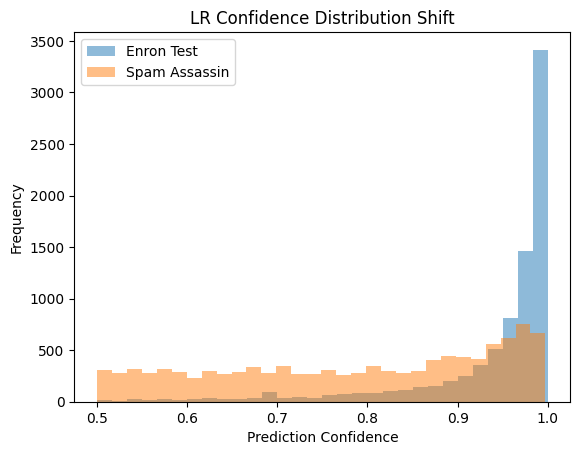

In [31]:
import matplotlib.pyplot as plt

plt.hist(lr_enron_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(lr_ood_conf, bins=30, alpha=0.5, label="Spam Assassin")
plt.legend()
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("LR Confidence Distribution Shift")
plt.show()

In [51]:
from sklearn.metrics import brier_score_loss

lr_enron_brier = brier_score_loss(y_test, lr_enron_proba[:,1])
lr_ood_brier = brier_score_loss(y_ood, lr_ood_proba[:,1])

print("Enron Brier:", lr_enron_brier)
print("SA Brier:", lr_ood_brier)

Enron Brier: 0.017968409114259173
SA Brier: 0.2959512430093774


N-Gram

In [34]:

# Validation predictions
ngram_enron_proba = char_ngram_model.predict_proba(X_test)
ngram_enron_conf = ngram_enron_proba.max(axis=1)

# Test predictions
ngram_ood_proba = char_ngram_model.predict_proba(X_ood)
ngram_ood_conf = ngram_ood_proba.max(axis=1)

print("Enron mean confidence:", ngram_enron_conf.mean())
print("Spam Assasin mean confidence:", ngram_ood_conf.mean())
print("Confidence shift:", ngram_ood_conf.mean() - ngram_enron_conf.mean())

Enron mean confidence: 0.9405069895653352
Spam Assasin mean confidence: 0.8317711550271744
Confidence shift: -0.10873583453816082


In [35]:
print("Enron confidence stats:", summarize_conf(ngram_enron_conf))
print("Test confidence stats:", summarize_conf(ngram_ood_conf))

Enron confidence stats: {'mean': np.float64(0.9405069895653352), 'std': np.float64(0.08621864900892166), 'min': np.float64(0.5003357267194363), '25%': np.float64(0.9306776218883581), '50%': np.float64(0.9741118570549493), '75%': np.float64(0.9908841665541148), 'max': np.float64(0.9999588990891926)}
Test confidence stats: {'mean': np.float64(0.8317711550271744), 'std': np.float64(0.13430675737619918), 'min': np.float64(0.5001542365893904), '25%': np.float64(0.7416104228863576), '50%': np.float64(0.8541685465060697), '75%': np.float64(0.9571874417310468), 'max': np.float64(0.9989975786944247)}


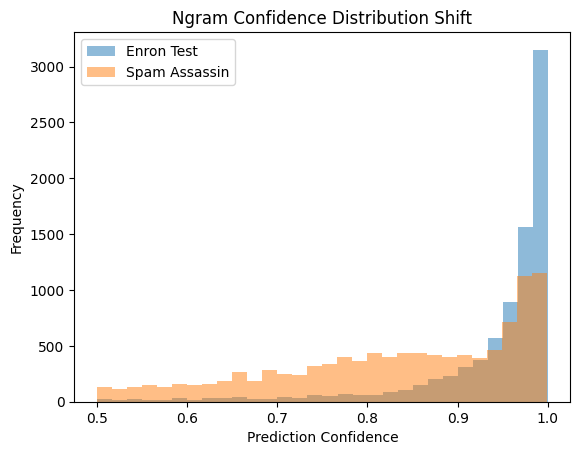

In [36]:
import matplotlib.pyplot as plt

plt.hist(ngram_enron_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(ngram_ood_conf, bins=30, alpha=0.5, label="Spam Assassin")
plt.legend()
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Ngram Confidence Distribution Shift")
plt.show()

In [53]:
from sklearn.metrics import brier_score_loss

ngram_enron_brier = brier_score_loss(y_test, ngram_enron_proba[:,1])
ngram_ood_brier = brier_score_loss(y_ood, ngram_ood_proba[:,1])

print("Enron Brier:", ngram_enron_brier)
print("SA Brier:", ngram_ood_brier)

Enron Brier: 0.016353536667537548
SA Brier: 0.3830821992817551


#### DistilBert

In [37]:
import torch
import numpy as np
from torch.nn.functional import softmax

def get_confidence(model, dataloader, device):
    model.eval()
    confidences = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)

            logits = outputs.logits
            probs = softmax(logits, dim=1)

            batch_conf = probs.max(dim=1).values
            confidences.extend(batch_conf.cpu().numpy())

    return np.array(confidences)

In [38]:
from torch.utils.data import DataLoader


X_val = X_test.copy().reset_index(drop=True)
X_test_final = X_ood.copy().reset_index(drop=True)

class SpamDataset(torch.utils.data.Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts.iloc[idx]

def collate_fn(batch):
    encoding = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    return {
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"]
    }

enron_dataset = SpamDataset(X_val)
ood_dataset = SpamDataset(X_test_final)

enron_dataloader = DataLoader(enron_dataset, batch_size=32, collate_fn=collate_fn)
ood_dataloader = DataLoader(ood_dataset, batch_size=32, collate_fn=collate_fn)

bert_enron_conf = get_confidence(model, enron_dataloader, device)
bert_ood_conf = get_confidence(model, ood_dataloader, device)

print("Enron mean confidence:", bert_enron_conf.mean())
print("Spam Assasin mean confidence:", bert_ood_conf.mean())
print("Confidence shift:", bert_ood_conf.mean() - bert_enron_conf.mean())

Enron mean confidence: 0.9924007
Spam Assasin mean confidence: 0.9991298
Confidence shift: 0.0067290664


In [39]:
print("Enron stats:", summarize_conf(bert_enron_conf))
print("Spam Assasin stats:", summarize_conf(bert_ood_conf))

Enron stats: {'mean': np.float32(0.9924007), 'std': np.float32(0.04480917), 'min': np.float32(0.5156828), '25%': np.float32(0.9998325), '50%': np.float32(0.99988115), '75%': np.float32(0.9998927), 'max': np.float32(0.9999474)}
Spam Assasin stats: {'mean': np.float32(0.9991298), 'std': np.float32(0.01462012), 'min': np.float32(0.5196709), '25%': np.float32(0.9998622), '50%': np.float32(0.9998754), '75%': np.float32(0.9998821), 'max': np.float32(0.99989474)}


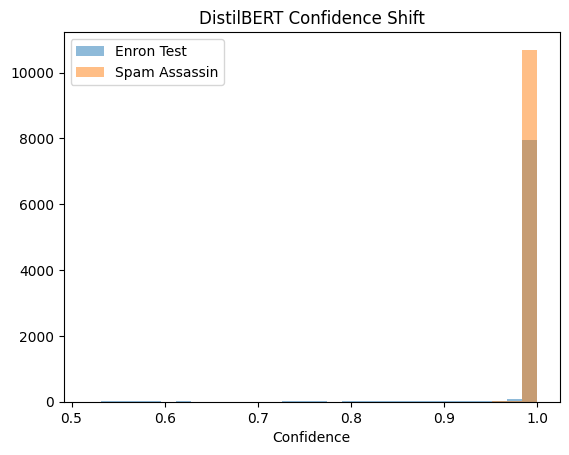

In [40]:
import matplotlib.pyplot as plt

plt.hist(bert_enron_conf, bins=30, alpha=0.5, label="Enron Test")
plt.hist(bert_ood_conf, bins=30, alpha=0.5, label="Spam Assassin")
plt.legend()
plt.xlabel("Confidence")
plt.title("DistilBERT Confidence Shift")
plt.show()

In [47]:
def get_probabilities(model, dataloader, device):
    model.eval()
    probs = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)

            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=1)[:, 1]

            probs.extend(probabilities.cpu().numpy())

    return np.array(probs)

In [48]:
from sklearn.metrics import brier_score_loss

enron_probs = get_probabilities(model, enron_dataloader, device)
ood_probs = get_probabilities(model, ood_dataloader, device)



In [49]:
bert_enron_brier = brier_score_loss(y_test, enron_probs)
bert_ood_brier = brier_score_loss(y_ood, ood_probs)

print("Enron Brier score:", bert_enron_brier)
print("Spam Assassin Brier score:", bert_ood_brier)
print("Brier shift:", bert_ood_brier - bert_enron_brier)

Enron Brier score: 0.08575977819091005
Spam Assassin Brier score: 0.645639148684255
Brier shift: 0.5598793704933449


In [54]:

print("In-distribution Brier (Enron test split):")
print(f"  NB:         {nb_enron_brier:.4f}")
print(f"  LR:         {lr_enron_brier:.4f}")
print(f"  NGram:      {ngram_enron_brier:.4f}")
print(f"  DistilBERT: {bert_enron_brier:.4f}")
print("Out-of-distribution Brier (Spam Assasin):")
print(f"  NB:         {nb_ood_brier:.4f}")
print(f"  LR:         {lr_ood_brier:.4f}")
print(f"  NGram:      {ngram_ood_brier:.4f}")
print(f"  DistilBERT: {bert_ood_brier:.4f}")
# ── Brier on 2021 (all-spam by design — interpret with caution) ─────────
# These are calibration scores under shift, where ground truth is all-spam
print("\nOut-of-distribution Brier (2021 spam-only — ground truth is all-spam):")
print("NOTE: All values measure calibration on spam class only, not balanced performance.")

In-distribution Brier (Enron test split):
  NB:         0.0198
  LR:         0.0180
  NGram:      0.0164
  DistilBERT: 0.0858
Out-of-distribution Brier (Spam Assasin):
  NB:         0.3595
  LR:         0.2960
  NGram:      0.3831
  DistilBERT: 0.6456

Out-of-distribution Brier (2021 spam-only — ground truth is all-spam):
NOTE: All values measure calibration on spam class only, not balanced performance.


# Semantic Embedding & Topic Modelling for Concept Drift Detection

This section implements an unsupervised drift detection layer using:
- **Sentence-BERT** (`all-MiniLM-L6-v2`) for dense semantic email representations
- **LDA** topic modelling to establish a baseline topic distribution over the training corpus
- **Jensen-Shannon divergence** to measure semantic shift between the training baseline and incoming monthly batches
- Drift signalling, divergent topic isolation, low-confidence flagging, and longitudinal logging

In [ ]:
!pip install sentence-transformers scikit-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial.distance import jensenshannon

Prepare Training Corpus and Incoming Monthly Batches

In [ ]:

train_texts = (train_df['Subject'].fillna('') + ' ' + train_df['Message'].fillna('')).tolist()
test_texts  = (test_df['Subject'].fillna('')  + ' ' + test_df['Message'].fillna('')).tolist()

# Create rolling monthly batches from test_df
test_df_copy = test_df.copy()
test_df_copy['YearMonth'] = test_df_copy['Date'].dt.to_period('M')
monthly_batches = {
    str(period): group[['Message', 'label']].copy()
    for period, group in test_df_copy.groupby('YearMonth')
}

print(f'Training corpus size     : {len(train_texts):,}')
print(f'Incoming stream size     : {len(test_texts):,}')
print(f'Number of monthly batches: {len(monthly_batches)}')
print('Sample batch keys:', list(monthly_batches.keys())[:5])

Training corpus size     : 25,008
Incoming stream size     : 8,337
Number of monthly batches: 60
Sample batch keys: ['1999-12', '2000-01', '2000-02', '2000-03', '2000-04']


##Encode Emails with Sentence-BERT
using  `all-MiniLM-L6-v2`, a lightweight Sentence-BERT model, to produce 384-dimensional
semantic embeddings. These capture semantic intent rather than surface token patterns,
making them sensitive to narrative-level drift (e.g. financial phishing -> health spam).

In [ ]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding training corpus (sample of 3000 for speed)...')
train_sample = [t[:512] for t in train_texts[:3000]]
train_embeddings = sbert_model.encode(
    train_sample, batch_size=64, show_progress_bar=True, convert_to_numpy=True
)

print(f'Training embeddings shape: {train_embeddings.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding training corpus (sample of 3000 for speed)...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Training embeddings shape: (3000, 384)


## Fit LDA Topic Model on Training Corpus

An LDA model is fitted on the training corpus to establish a **baseline topic distribution**.
Each document is a probability vector over K topics; the mean across all training documents
forms the reference distribution against which incoming batches are compared.

In [ ]:
N_TOPICS = 15  # Tunable — more topics = finer semantic resolution

vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 1)
)

train_dtm = vectorizer.fit_transform(train_sample)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online'
)
lda.fit(train_dtm)

# Baseline distribution: mean doc-topic vector over training set
train_topic_dist   = lda.transform(train_dtm)
baseline_topic_dist = train_topic_dist.mean(axis=0)
baseline_topic_dist /= baseline_topic_dist.sum()

print('Baseline topic distribution (prob per topic):')
for i, p in enumerate(baseline_topic_dist):
    print(f'  Topic {i:02d}: {p:.4f}')

Baseline topic distribution (prob per topic):
  Topic 00: 0.1796
  Topic 01: 0.0261
  Topic 02: 0.0954
  Topic 03: 0.0687
  Topic 04: 0.0517
  Topic 05: 0.0797
  Topic 06: 0.0577
  Topic 07: 0.0216
  Topic 08: 0.1011
  Topic 09: 0.0315
  Topic 10: 0.0359
  Topic 11: 0.0217
  Topic 12: 0.0624
  Topic 13: 0.0484
  Topic 14: 0.1187


In [ ]:
# Inspect top words per topic for interpretability
feature_names = vectorizer.get_feature_names_out()

def print_top_words(model, feature_names, n_top=8):
    print('Top words per LDA topic (training baseline):')
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top - 1:-1]]
        print(f'  Topic {topic_idx:02d}: {", ".join(top_words)}')

print_top_words(lda, feature_names)

Top words per LDA topic (training baseline):
  Topic 00: time, power, enron, gas, just, know, today, group
  Topic 01: hpl, xls, nom, attached, file, penis, size, meter
  Topic 02: http, best, com, home, credit, new, time, rate
  Topic 03: software, 00, stock, adobe, windows, xp, professional, 60
  Topic 04: date, start, hour, hourahead, final, schedules, california, schedule
  Topic 05: com, mail, message, energy, email, gas, send, new
  Topic 06: website, online, save, http, www, day, search, site
  Topic 07: la, en, www, takes, fit, net, el, st
  Topic 08: sent, message, original, louise, 2001, fw, list, attached
  Topic 09: project, work, year, great, 2001, chris, body, good
  Topic 10: quality, meds, prices, generic, stop, online, medications, medication
  Topic 11: price, oo, computer, high, softwares, 95, pi, mobile
  Topic 12: click, life, business, free, new, logo, just, web
  Topic 13: account, dear, bank, mr, number, 2005, international, 45
  Topic 14: ect, enron, 2000, hou,

## Jensen-Shannon Divergence Drift Monitor

For each incoming monthly batch:
1. Transform the batch through the *frozen* LDA model.
2. Compute Jensen-Shannon divergence between the batch mean topic vector and the baseline.
3. Compare JS divergence to a threshold — if exceeded, a drift signal is triggered.
4. Identify which topics are contributing most to the divergence for interpretable reporting.

In [ ]:
JS_THRESHOLD = 0.25   # Tunable: lower = more sensitive
WINDOW_SIZE  = 100    # Minimum batch size to evaluate drift

drift_log = []

def compute_js_divergence(p, q):
    p = np.asarray(p, dtype=float) + 1e-10
    q = np.asarray(q, dtype=float) + 1e-10
    p /= p.sum(); q /= q.sum()
    return float(jensenshannon(p, q))


def detect_drift(batch_texts, batch_labels, period_label, baseline_dist,
                 vectorizer, lda_model, threshold=JS_THRESHOLD):
    if len(batch_texts) < WINDOW_SIZE:
        return None

    texts_clean = [str(t)[:512] for t in batch_texts]
    dtm = vectorizer.transform(texts_clean)
    topic_dist = lda_model.transform(dtm).mean(axis=0)
    topic_dist /= topic_dist.sum()

    js_div = compute_js_divergence(baseline_dist, topic_dist)
    drift  = js_div > threshold

    topic_delta     = np.abs(topic_dist - baseline_dist)
    divergent_topics = np.argsort(topic_delta)[::-1][:3].tolist()

    return {
        'period'           : period_label,
        'n_emails'         : len(batch_texts),
        'js_divergence'    : round(js_div, 5),
        'drift_detected'   : drift,
        'batch_topic_dist' : topic_dist.tolist(),
        'divergent_topics' : divergent_topics,
        'spam_rate'        : float(np.mean(batch_labels)) if batch_labels is not None else None
    }


In [ ]:
# Run drift monitor across all monthly batches
for period, batch_df in sorted(monthly_batches.items()):
    result = detect_drift(
        batch_df['Message'].tolist(),
        batch_df['label'].tolist(),
        period_label=period,
        baseline_dist=baseline_topic_dist,
        vectorizer=vectorizer,
        lda_model=lda
    )
    if result is not None:
        drift_log.append(result)
        status = 'DRIFT DETECTED' if result['drift_detected'] else 'stable'
        print(f"{result['period']}  JS={result['js_divergence']:.4f}  "
              f"n={result['n_emails']:4d}  {status}")

2000-03  JS=0.2781  n= 121  DRIFT DETECTED
2000-04  JS=0.2816  n= 102  DRIFT DETECTED
2000-06  JS=0.2723  n= 179  DRIFT DETECTED
2000-07  JS=0.2603  n= 141  DRIFT DETECTED
2000-08  JS=0.2569  n= 159  DRIFT DETECTED
2000-09  JS=0.2707  n= 145  DRIFT DETECTED
2000-10  JS=0.2749  n= 201  DRIFT DETECTED
2000-11  JS=0.2651  n= 188  DRIFT DETECTED
2000-12  JS=0.2536  n= 147  DRIFT DETECTED
2001-01  JS=0.2318  n= 213  stable
2001-02  JS=0.2398  n= 124  stable
2001-03  JS=0.2607  n= 237  DRIFT DETECTED
2001-04  JS=0.2487  n= 276  stable
2001-05  JS=0.2356  n= 152  stable
2001-06  JS=0.2459  n= 109  stable
2001-07  JS=0.2221  n= 170  stable
2001-08  JS=0.2143  n= 150  stable
2001-09  JS=0.2813  n= 144  DRIFT DETECTED
2001-10  JS=0.2501  n= 198  DRIFT DETECTED
2001-11  JS=0.2609  n= 161  DRIFT DETECTED
2001-12  JS=0.4090  n= 179  DRIFT DETECTED
2002-01  JS=0.3988  n= 255  DRIFT DETECTED
2002-07  JS=0.2393  n= 100  stable
2004-08  JS=0.2241  n= 184  stable
2004-09  JS=0.2357  n= 182  stable
2004-

## Visualise Drift Over Time

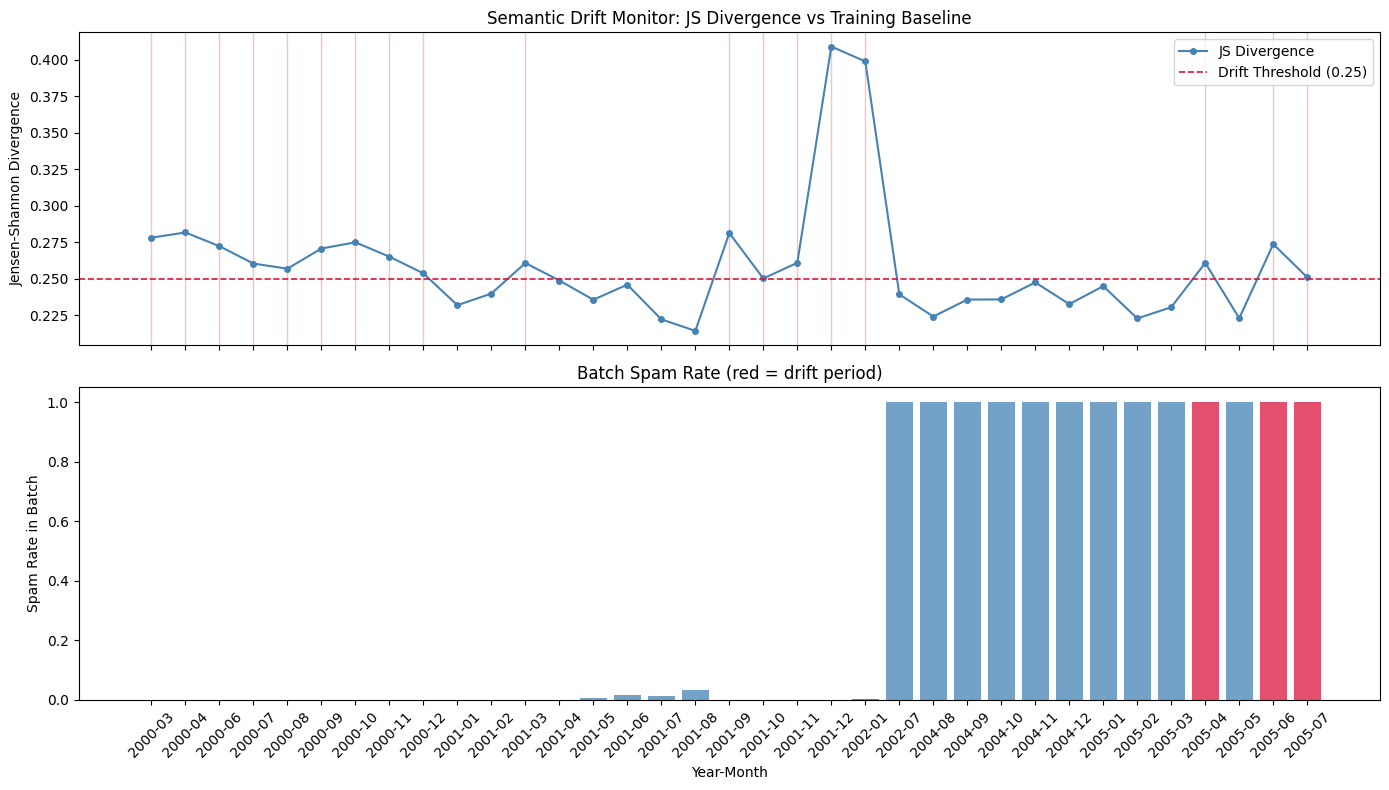

Saved: drift_monitor.png


In [ ]:
drift_df = pd.DataFrame(drift_log)
drift_df['period'] = drift_df['period'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(drift_df['period'], drift_df['js_divergence'], marker='o',
        color='steelblue', linewidth=1.5, markersize=4, label='JS Divergence')
ax.axhline(JS_THRESHOLD, color='crimson', linestyle='--', linewidth=1.2,
           label=f'Drift Threshold ({JS_THRESHOLD})')
for _, row in drift_df[drift_df['drift_detected']].iterrows():
    ax.axvspan(row['period'], row['period'], alpha=0.25, color='red')
ax.set_ylabel('Jensen-Shannon Divergence')
ax.set_title('Semantic Drift Monitor: JS Divergence vs Training Baseline')
ax.legend()
ax.tick_params(axis='x', rotation=45)

ax2 = axes[1]
colors_bar = ['crimson' if d else 'steelblue' for d in drift_df['drift_detected']]
ax2.bar(drift_df['period'], drift_df['spam_rate'], color=colors_bar, alpha=0.75, width=0.8)
ax2.set_ylabel('Spam Rate in Batch')
ax2.set_xlabel('Year-Month')
ax2.set_title('Batch Spam Rate (red = drift period)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('drift_monitor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: drift_monitor.png')

In [ ]:
n_drift  = drift_df['drift_detected'].sum()
n_stable = (~drift_df['drift_detected']).sum()
max_row  = drift_df.loc[drift_df['js_divergence'].idxmax()]

print('=== Drift Detection Summary ===')
print(f'Total batches evaluated : {len(drift_df)}')
print(f'Drift detected          : {n_drift}  ({100*n_drift/len(drift_df):.1f}%)')
print(f'Stable batches          : {n_stable}')
print(f'Max JS divergence       : {max_row["js_divergence"]:.5f} ({max_row["period"]})')
print()
print('Periods flagged for drift with leading divergent topic:')
for _, row in drift_df[drift_df['drift_detected']].iterrows():
    tid   = row['divergent_topics'][0]
    words = [feature_names[i] for i in lda.components_[tid].argsort()[:-6:-1]]
    print(f"  {row['period']}  JS={row['js_divergence']:.4f}  "
          f"Leading topic {tid}: {', '.join(words)}")

=== Drift Detection Summary ===
Total batches evaluated : 35
Drift detected          : 18  (51.4%)
Stable batches          : 17
Max JS divergence       : 0.40900 (2001-12)

Periods flagged for drift with leading divergent topic:
  2000-03  JS=0.2781  Leading topic 14: ect, enron, 2000, hou, vince
  2000-04  JS=0.2816  Leading topic 14: ect, enron, 2000, hou, vince
  2000-06  JS=0.2723  Leading topic 14: ect, enron, 2000, hou, vince
  2000-07  JS=0.2603  Leading topic 14: ect, enron, 2000, hou, vince
  2000-08  JS=0.2569  Leading topic 14: ect, enron, 2000, hou, vince
  2000-09  JS=0.2707  Leading topic 14: ect, enron, 2000, hou, vince
  2000-10  JS=0.2749  Leading topic 14: ect, enron, 2000, hou, vince
  2000-11  JS=0.2651  Leading topic 14: ect, enron, 2000, hou, vince
  2000-12  JS=0.2536  Leading topic 14: ect, enron, 2000, hou, vince
  2001-03  JS=0.2607  Leading topic 14: ect, enron, 2000, hou, vince
  2001-09  JS=0.2813  Leading topic 8: sent, message, original, louise, 2001
  20

In [ ]:
# Low-confidence flagging for drift periods
drift_periods = set(drift_df[drift_df['drift_detected']]['period'].tolist())

test_df_reset = test_df.copy().reset_index(drop=True)
test_df_reset['YearMonth'] = test_df_reset['Date'].dt.to_period('M').astype(str)
test_df_reset['drift_flag'] = test_df_reset['YearMonth'].isin(drift_periods)

print(f'Emails in drift periods  : {test_df_reset["drift_flag"].sum():,}')
print(f'Emails in stable periods : {(~test_df_reset["drift_flag"]).sum():,}')
print('Sample flagged records:')
test_df_reset[test_df_reset['drift_flag']][['Date', 'YearMonth', 'label', 'drift_flag']].head(5)

Emails in drift periods  : 4,020
Emails in stable periods : 4,317
Sample flagged records:


,Date,YearMonth,label,drift_flag
0,2000-12-05,2000-12,0,True
2,2001-09-13,2001-09,0,True
3,2005-06-29,2005-06,1,True
5,2000-10-03,2000-10,0,True
6,2000-10-03,2000-10,0,True


In [ ]:
# Export longitudinal drift log
drift_df[['period', 'n_emails', 'js_divergence', 'drift_detected',
          'divergent_topics', 'spam_rate']].to_csv('drift_log.csv', index=False)
print('Drift log saved to drift_log.csv')
drift_df[['period', 'n_emails', 'js_divergence', 'drift_detected', 'spam_rate']].round(4)

Drift log saved to drift_log.csv


,period,n_emails,js_divergence,drift_detected,spam_rate
0,2000-03,121,0.2781,True,0.0000
1,2000-04,102,0.2816,True,0.0000
2,2000-06,179,0.2723,True,0.0000
3,2000-07,141,0.2603,True,0.0000
4,2000-08,159,0.2568,True,0.0000
5,2000-09,145,0.2706,True,0.0000
6,2000-10,201,0.2749,True,0.0000
7,2000-11,188,0.2651,True,0.0000
8,2000-12,147,0.2536,True,0.0000
9,2001-01,213,0.2318,False,0.0000


---
#LLM-Based Probability Refinement

This section implements a **two-stage hybrid inference system**:

1. **Stage 1 — Base classifier** (DistilBERT): produces an initial spam probability for every email.
2. **Stage 2 — LLM auditor** (`gpt-4o-mini` via OPENAI API): invoked *selectively* on
   uncertain or drift-flagged emails to output a calibrated secondary probability estimate.

The final decision is a weighted blend:
$$p_{\text{final}} = w_{\text{base}} \cdot p_{\text{BERT}} + w_{\text{LLM}} \cdot p_{\text{LLM}}$$

High-confidence predictions bypass the LLM entirely, preserving computational efficiency.

In [ ]:
!pip install openai -q

In [ ]:
import openai
import re
import time

# Set your OpenAI API key via Colab secrets or environment variable:
#   from google.colab import userdata
#   OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
#   -- OR --
#   import os; os.environ['OPENAI_API_KEY'] = 'sk-...'

try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
except Exception:
    import os
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')

if not OPENAI_API_KEY:
    print('[WARNING] OPENAI_API_KEY not set. LLM refinement calls will be skipped.')
else:
    openai.api_key = OPENAI_API_KEY
    print('OpenAI API key found.')

OpenAI API key found.


##Collect DistilBERT Probabilities and Identify Uncertainty Band

We run DistilBERT across the test set and identify two routing criteria:
- **Uncertainty band**: `0.30 <= p(spam) <= 0.70` — the model is insufficiently confident.
- **Drift flag**: the email falls in a period where JS divergence exceeded the threshold.

Only emails meeting at least one criterion are forwarded to the LLM layer.

In [ ]:
UNCERTAINTY_LOW  = 0.15
UNCERTAINTY_HIGH = 0.85
LLM_WEIGHT  = 0.60   # Weight of LLM estimate in final blend
BASE_WEIGHT = 0.40   # Weight of DistilBERT estimate


def get_bert_probs_batch(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_probs = []
    texts_clean = [str(t)[:512] for t in texts]
    for i in range(0, len(texts_clean), batch_size):
        batch = texts_clean[i:i+batch_size]
        enc = tokenizer(
            batch, truncation=True, padding=True,
            max_length=256, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)


print('Getting DistilBERT probabilities on  test set...')
bert_test_probs = get_bert_probs_batch(
    test_df['Message'].tolist(), model, tokenizer, device
)

# Routing masks
uncertain_mask = (
    (bert_test_probs >= UNCERTAINTY_LOW) &
    (bert_test_probs <= UNCERTAINTY_HIGH)
)
drift_mask = test_df_reset['drift_flag'].values
refinement_mask = uncertain_mask | drift_mask

print(f'Total test emails          : {len(bert_test_probs):,}')
print(f'Uncertainty band emails    : {uncertain_mask.sum():,}')
print(f'Drift-period emails        : {drift_mask.sum():,}')
print(f'Emails routed to LLM layer : {refinement_mask.sum():,}  '
      f'({100*refinement_mask.mean():.1f}% of test set)')

Getting DistilBERT probabilities on  test set...
Total test emails          : 8,337
Uncertainty band emails    : 30
Drift-period emails        : 4,020
Emails routed to LLM layer : 4,042  (48.5% of test set)


##LLM Probability Refinement Function

Each routed email is sent to `gpt-4o-mini` with a structured prompt that provides the
email content, the base model probability, and explicit reasoning instructions. The model
outputs a calibrated probability using a parseable format.

### ══════════════════════════════════════════════════════════════════════
### SECTION: LLM-Assisted Calibration (Preliminary / Supporting Analysis)
### This section is treated as exploratory. Results are conditional on
### OPENAI_API_KEY availability and a small evaluation subset.
### ══════════════════════════════════════════════════════════════════════

In [ ]:
SYSTEM_PROMPT = """\
You are a spam detection calibration assistant.
Given an email and a base model spam probability, your task is to:
1. Reason briefly about the email's content, tone, intent, and spam indicators.
2. Output a CALIBRATED spam probability between 0.0 and 1.0 as a single float.

Focus especially on:
- Persuasion tactics, urgency language, or financial lures
- Suspicious sender patterns, off-topic padding, or obfuscated text
- Phishing narratives or health/financial content patterns

End your response with EXACTLY this line:
CALIBRATED_PROBABILITY: <float between 0.0 and 1.0>
"""


def extract_probability(text):
    match = re.search(r'CALIBRATED_PROBABILITY:\s*([0-9]*\.?[0-9]+)', text)
    if match:
        return float(np.clip(float(match.group(1)), 0.0, 1.0))
    return None


def llm_refine_probability(email_text, base_prob, client, max_retries=2):
    user_message = (
        f'Email text (truncated to 600 chars):\n{str(email_text)[:600]}\n\n'
        f'Base model spam probability: {base_prob:.4f}\n\n'
        f'Please reason about this email and provide your calibrated probability.'
    )
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model='gpt-4o-mini',
                max_tokens=300,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': user_message}
                ]
            )
            reply = response.choices[0].message.content
            prob  = extract_probability(reply)
            if prob is not None:
                return prob, reply
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                print(f'  [LLM call failed]: {e}')
    return None, None

print('LLM refinement function defined.')

LLM refinement function defined.


## Run the Two-Stage Hybrid Pipeline

The LLM is invoked on a capped sample of routed emails to control API cost during experiments
(increase `MAX_LLM_CALLS` for full evaluation). The final probability blends both estimates.

In [ ]:
MAX_LLM_CALLS = 30   # Increase for full evaluation; kept low to control API cost

results_hybrid = []
# BERT near-certain but not absolutely certain — its "soft edge"
soft_edge_mask = (
    ((bert_test_probs >= 0.85) & (bert_test_probs < 0.99)) |  # confident spam
    ((bert_test_probs <= 0.15) & (bert_test_probs > 0.01))    # confident ham
)
routed_indices = np.where(soft_edge_mask)[0][:MAX_LLM_CALLS]
if not OPENAI_API_KEY:
    print('[SKIP] No API key set. Assign OPENAI_API_KEY to run the LLM layer.')
else:
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    # routed_indices = np.where(refinement_mask)[0][:MAX_LLM_CALLS]
    print(f'Running LLM refinement on {len(routed_indices)} emails...\n')

    for idx in routed_indices:
        email_text = test_df_reset.loc[idx, 'Message']
        true_label = int(test_df_reset.loc[idx, 'label'])
        base_p     = float(bert_test_probs[idx])
        year_month = test_df_reset.loc[idx, 'YearMonth']

        llm_p, llm_reasoning = llm_refine_probability(email_text, base_p, client)

        final_p = (BASE_WEIGHT * base_p + LLM_WEIGHT * llm_p) if llm_p is not None else base_p

        results_hybrid.append({
            'index'         : idx,
            'period'        : year_month,
            'true_label'    : true_label,
            'base_prob'     : base_p,
            'llm_prob'      : llm_p,
            'final_prob'    : final_p,
            'drift_flagged' : bool(drift_mask[idx]),
            'uncertain'     : bool(uncertain_mask[idx]),
            'base_correct'  : int((base_p  >= 0.5) == true_label),
            'final_correct' : int((final_p >= 0.5) == true_label)
        })

        llm_str = f'{llm_p:.3f}' if llm_p is not None else 'N/A'
        print(f'  [{idx:4d}]  true={true_label}  base={base_p:.3f}  '
              f'llm={llm_str:>5}  final={final_p:.3f}  drift={drift_mask[idx]}')

    print(f'\nLLM refinement complete: {len(results_hybrid)} emails processed.')

Running LLM refinement on 30 emails...

  [  41]  true=0  base=0.927  llm=0.948  final=0.939  drift=False
  [ 159]  true=1  base=0.956  llm=0.981  final=0.971  drift=False
  [ 182]  true=1  base=0.977  llm=0.950  final=0.961  drift=True
  [ 215]  true=0  base=0.108  llm=0.320  final=0.235  drift=True
  [ 346]  true=1  base=0.917  llm=0.650  final=0.757  drift=False
  [ 444]  true=1  base=0.983  llm=0.850  final=0.903  drift=False
  [ 490]  true=1  base=0.852  llm=0.915  final=0.890  drift=True
  [ 569]  true=1  base=0.916  llm=0.950  final=0.936  drift=True
  [ 721]  true=1  base=0.904  llm=0.950  final=0.932  drift=False
  [ 780]  true=0  base=0.017  llm=0.030  final=0.025  drift=False
  [ 840]  true=1  base=0.951  llm=0.910  final=0.926  drift=False
  [ 896]  true=0  base=0.040  llm=0.275  final=0.181  drift=False
  [1296]  true=0  base=0.974  llm=0.950  final=0.960  drift=True
  [1328]  true=0  base=0.038  llm=0.025  final=0.030  drift=True
  [1336]  true=1  base=0.917  llm=0.100  f

##Calibration Analysis — Brier Score and Log-Loss

In [ ]:
from sklearn.metrics import brier_score_loss, log_loss

if results_hybrid:
    hybrid_df   = pd.DataFrame(results_hybrid)
    y_true      = hybrid_df['true_label'].values
    base_probs  = hybrid_df['base_prob'].values
    final_probs = hybrid_df['final_prob'].values

    base_brier  = brier_score_loss(y_true, base_probs)
    final_brier = brier_score_loss(y_true, final_probs)
    base_acc    = hybrid_df['base_correct'].mean()
    final_acc   = hybrid_df['final_correct'].mean()
    df_results = pd.DataFrame(results_hybrid)
    df_results['disagreement'] = (df_results['llm_prob'] - df_results['base_prob']).abs()
    df_results['prediction_flip'] = (
        (df_results['base_prob'] >= 0.5) != (df_results['final_prob'] >= 0.5)
    )

    # Most interesting: big disagreement AND a prediction flip
    print(df_results[df_results['prediction_flip']].sort_values('disagreement', ascending=False))
    try:
        base_ll  = log_loss(y_true, np.clip(base_probs, 1e-7, 1-1e-7))
        final_ll = log_loss(y_true, np.clip(final_probs, 1e-7, 1-1e-7))
    except Exception:
        base_ll = final_ll = float('nan')

    print('===== Two-Stage Hybrid Pipeline: Calibration Results =====')
    print(f'  Emails evaluated       : {len(hybrid_df)}')
    print(f'  Drift-flagged          : {hybrid_df["drift_flagged"].sum()}')
    print(f'  Uncertainty-band       : {hybrid_df["uncertain"].sum()}')
    print()
    print(f'  Base DistilBERT Brier  : {base_brier:.5f}')
    print(f'  Hybrid (LLM-blended)   : {final_brier:.5f}')
    print(f'  Brier improvement      : {base_brier - final_brier:+.5f}')
    print()
    print(f'  Base log-loss          : {base_ll:.5f}')
    print(f'  Hybrid log-loss        : {final_ll:.5f}')
    print()
    print(f'  Base accuracy (sample) : {base_acc:.3f}')
    print(f'  Hybrid accuracy        : {final_acc:.3f}')
else:
    print('[SKIP] No hybrid results. Set OPEN_AI_KEY and re-run.')

    index   period  true_label  base_prob  llm_prob  final_prob  \
14   1336  2004-12           1   0.917228       0.1    0.426891   
22   2124  2005-01           1   0.935901       0.2    0.494360   
17   1439  2005-01           1   0.917228       0.2    0.486891   

    drift_flagged  uncertain  base_correct  final_correct  disagreement  \
14          False      False             1              0      0.817228   
22          False      False             1              0      0.735901   
17          False      False             1              0      0.717228   

    prediction_flip  
14             True  
22             True  
17             True  
===== Two-Stage Hybrid Pipeline: Calibration Results =====
  Emails evaluated       : 30
  Drift-flagged          : 7
  Uncertainty-band       : 0

  Base DistilBERT Brier  : 0.14890
  Hybrid (LLM-blended)   : 0.16400
  Brier improvement      : -0.01509

  Base log-loss          : 0.53185
  Hybrid log-loss        : 0.52741

  Base accuracy 

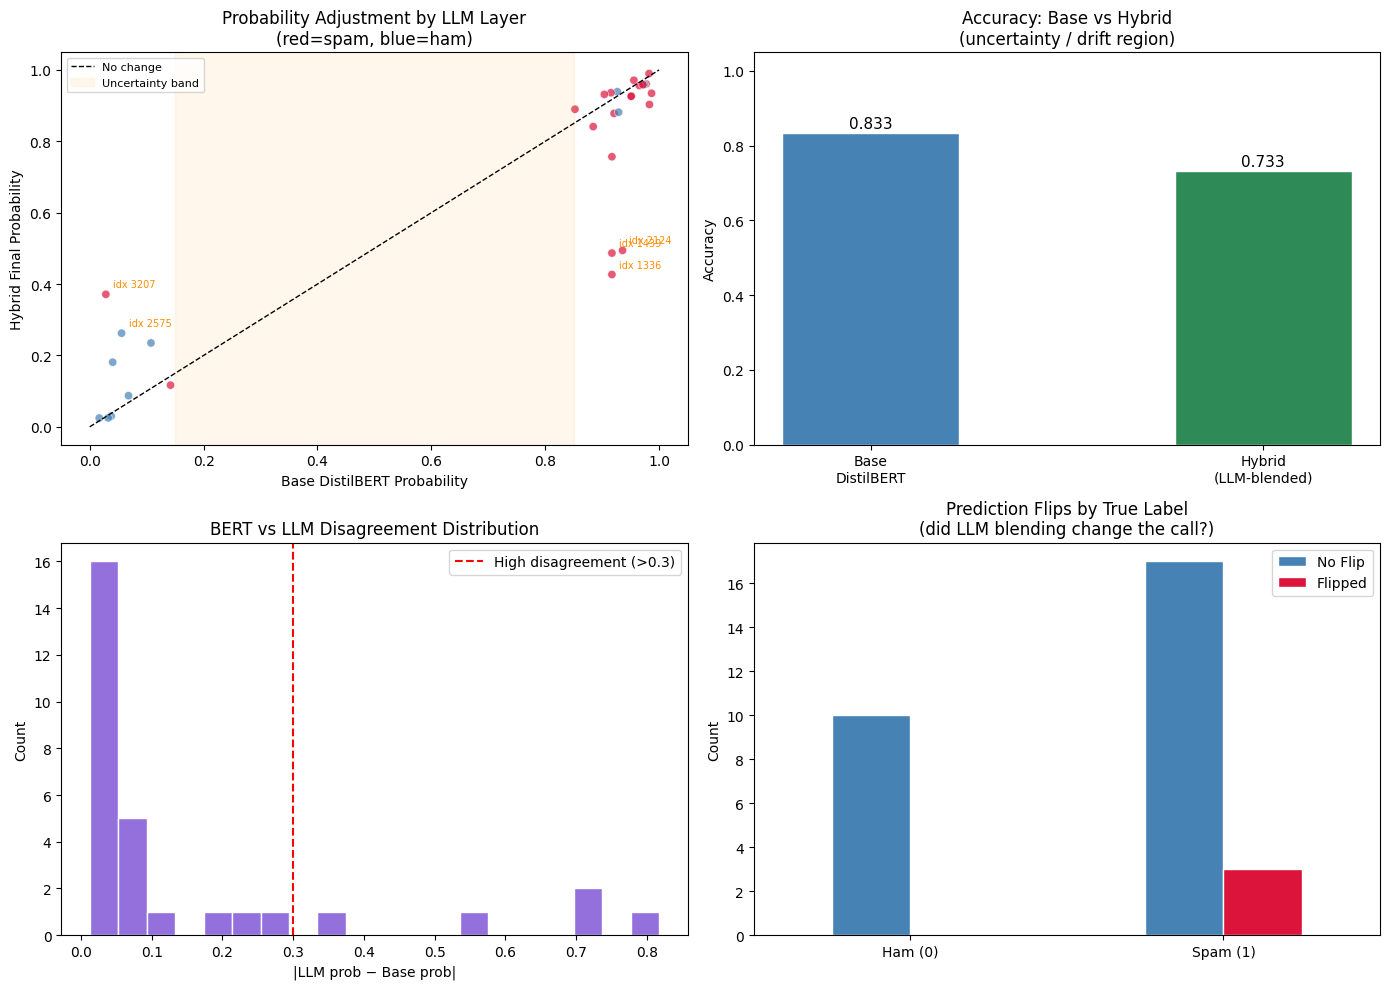

Saved: hybrid_refinement.png


In [ ]:
if results_hybrid:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Scatter: base vs hybrid probabilities ---
    ax = axes[0, 0]
    colors = ['crimson' if l == 1 else 'steelblue' for l in hybrid_df['true_label']]
    ax.scatter(hybrid_df['base_prob'], hybrid_df['final_prob'],
               c=colors, alpha=0.7, edgecolors='white', linewidths=0.5)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='No change')
    ax.axvspan(UNCERTAINTY_LOW, UNCERTAINTY_HIGH, alpha=0.08, color='orange',
               label='Uncertainty band')
    # Add this inside the scatter block
    for _, row in hybrid_df[df_results['disagreement'] > 0.3].iterrows():
        ax.annotate(f"idx {int(row['index'])}",
                    xy=(row['base_prob'], row['final_prob']),
                    fontsize=7, color='darkorange',
                    xytext=(5, 5), textcoords='offset points')
    ax.set_xlabel('Base DistilBERT Probability')
    ax.set_ylabel('Hybrid Final Probability')
    ax.set_title('Probability Adjustment by LLM Layer\n(red=spam, blue=ham)')
    ax.legend(fontsize=8)

    # --- Bar: accuracy comparison ---
    ax2 = axes[0, 1]
    labels_bar = ['Base\nDistilBERT', 'Hybrid\n(LLM-blended)']
    values_bar = [base_acc, final_acc]
    bars = ax2.bar(labels_bar, values_bar,
                   color=['steelblue', 'seagreen'], width=0.45, edgecolor='white')
    for bar, val in zip(bars, values_bar):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy: Base vs Hybrid\n(uncertainty / drift region)')

    ax3 = axes[1, 0]
    disagreement = (hybrid_df['llm_prob'] - hybrid_df['base_prob']).abs()
    ax3.hist(disagreement, bins=20, color='mediumpurple', edgecolor='white')
    ax3.axvline(0.3, color='red', linestyle='--', label='High disagreement (>0.3)')
    ax3.set_xlabel('|LLM prob − Base prob|')
    ax3.set_ylabel('Count')
    ax3.set_title('BERT vs LLM Disagreement Distribution')
    ax3.legend()

    # --- NEW: flip analysis by true label ---
    ax4 = axes[1, 1]
    hybrid_df['prediction_flip'] = (
        (hybrid_df['base_prob'] >= 0.5) != (hybrid_df['final_prob'] >= 0.5)
    )
    flip_counts = hybrid_df.groupby(['true_label', 'prediction_flip']).size().unstack(fill_value=0)
    flip_counts.index = ['Ham (0)', 'Spam (1)']
    flip_counts.columns = ['No Flip', 'Flipped']
    flip_counts.plot(kind='bar', ax=ax4, color=['steelblue', 'crimson'],
                    edgecolor='white', rot=0)
    ax4.set_title('Prediction Flips by True Label\n(did LLM blending change the call?)')
    ax4.set_ylabel('Count')
    ax4.legend()

    plt.tight_layout()
    plt.savefig('hybrid_refinement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: hybrid_refinement.png')
else:
    print('[SKIP] Set OPENAI_API_KEY to generate visualisations.')

##Full Pipeline Decision Table

Each row shows the routing decision, base probability, LLM calibration, final blended probability,
whether drift or uncertainty triggered LLM routing, and per-email accuracy gain.

In [ ]:
if results_hybrid:
    pd.set_option('display.float_format', '{:.4f}'.format)
    cols = ['period', 'true_label', 'base_prob', 'llm_prob', 'final_prob',
            'drift_flagged', 'uncertain', 'base_correct', 'final_correct']
    hybrid_df[cols].round(4)
else:
    print('[SKIP] No results available. Run with OPENAI_API_KEY set.')

In [ ]:
if results_hybrid:
    hybrid_df.to_csv('hybrid_refinement_results.csv', index=False)
    print('Hybrid refinement results saved to hybrid_refinement_results.csv')

Hybrid refinement results saved to hybrid_refinement_results.csv


## Shap
SHAP (SHapley Additive exPlanations) assigns each feature a contribution score to a specific prediction, grounded in cooperative game theory.

In [ ]:
def evaluate_bert_probs(texts):
    """Wrapper for SHAP — takes a list of strings, returns (n, 2) probability array."""
    probs_spam = get_bert_probs_batch(texts, model, tokenizer, device)
    probs_ham  = 1 - probs_spam
    return np.stack([probs_ham, probs_spam], axis=1)

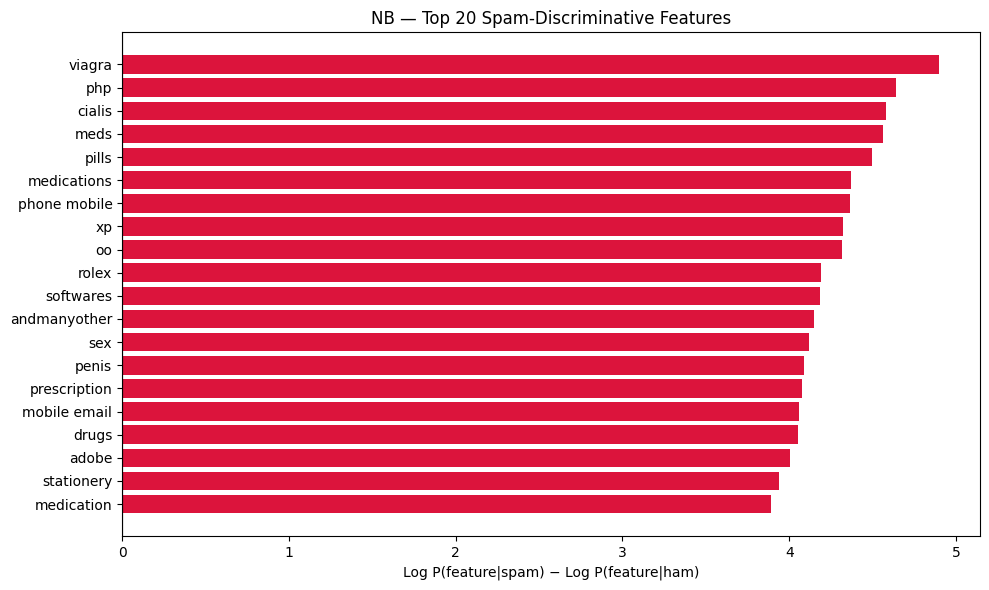

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# For MultinomialNB, feature_log_prob_ gives the log probability of each
# feature given each class. The difference between spam and ham log probs
# is directly interpretable as a spam signal strength — equivalent to SHAP.

feature_names   = nb_model["tfidf"].get_feature_names_out()
log_prob_ham    = nb_model["nb"].feature_log_prob_[0]   # P(feature | ham)
log_prob_spam   = nb_model["nb"].feature_log_prob_[1]   # P(feature | spam)

# Difference: positive = more likely in spam than ham
spam_signal = log_prob_spam - log_prob_ham

top_idx   = np.argsort(spam_signal)[-20:][::-1]
top_names = feature_names[top_idx]
top_vals  = spam_signal[top_idx]

plt.figure(figsize=(10, 6))
colors = ["crimson" if v > 0 else "steelblue" for v in top_vals]
plt.barh(top_names[::-1], top_vals[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Log P(feature|spam) − Log P(feature|ham)")
plt.title("NB — Top 20 Spam-Discriminative Features")
plt.tight_layout()
plt.savefig("nb_shap.png", dpi=150, bbox_inches="tight")
plt.show()

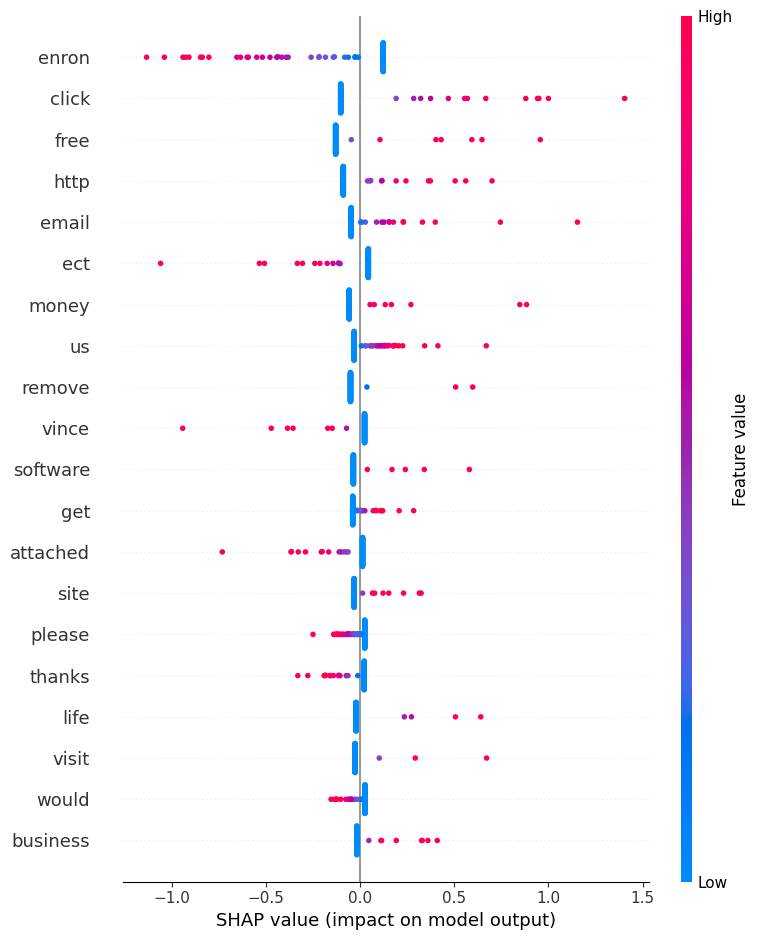

PartitionExplainer explainer:  25%|██▌       | 5/20 [00:16<00:20,  1.39s/it]Token indices sequence length is longer than the specified maximum sequence length for this model (1173 > 512). Running this sequence through the model will result in indexing errors
PartitionExplainer explainer: 21it [00:49,  2.61s/it]


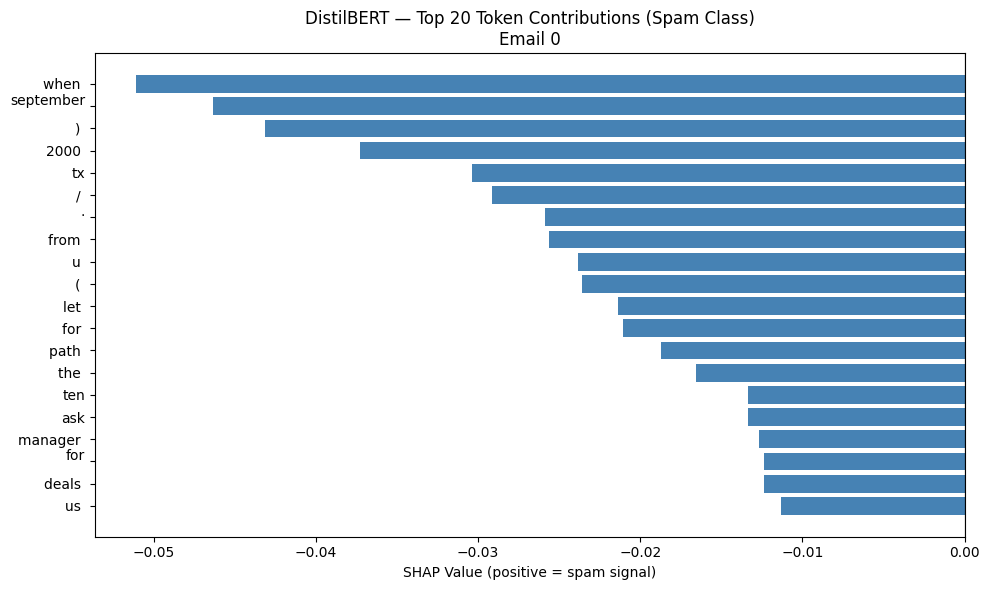

In [ ]:
import shap
import numpy as np

# ── Logistic Regression SHAP ──────────────────────────────────
X_train_tfidf_lr = lr_model["tfidf"].transform(X_train).toarray()
X_test_tfidf_lr  = lr_model["tfidf"].transform(X_test[:100]).toarray()

lr_explainer   = shap.LinearExplainer(lr_model["lr"], X_train_tfidf_lr)
lr_shap_values = lr_explainer.shap_values(X_test_tfidf_lr)

shap.summary_plot(
    lr_shap_values,
    features=X_test_tfidf_lr,
    feature_names=lr_model["tfidf"].get_feature_names_out(),
    title="LR — SHAP Feature Importance"
)

# ── DistilBERT SHAP ───────────────────────────────────────────
bert_explainer = shap.Explainer(
    lambda x: evaluate_bert_probs(x),
    shap.maskers.Text(tokenizer)
)
bert_shap_values = bert_explainer(test_df["Message"][:20])
# ── DistilBERT SHAP — clean bar chart ────────────────────────
import pandas as pd

# bert_shap_values[0] = first email, output 1 = spam class
shap_vals   = bert_shap_values[0, :, 1]   # spam class SHAP values
token_names = bert_shap_values.data[0]     # corresponding tokens

# Build DataFrame and aggregate by token (same token may appear multiple times)
shap_df = pd.DataFrame({
    "token": token_names,
    "shap":  shap_vals.values
})

shap_df = (
    shap_df.groupby("token")["shap"]
    .mean()
    .reset_index()
    .sort_values("shap", key=abs, ascending=False)
    .head(20)
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["crimson" if v > 0 else "steelblue" for v in shap_df["shap"]]
ax.barh(shap_df["token"][::-1], shap_df["shap"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP Value (positive = spam signal)")
ax.set_title("DistilBERT — Top 20 Token Contributions (Spam Class)\nEmail 0")
plt.tight_layout()
plt.savefig("bert_shap.png", dpi=150, bbox_inches="tight")
plt.show()

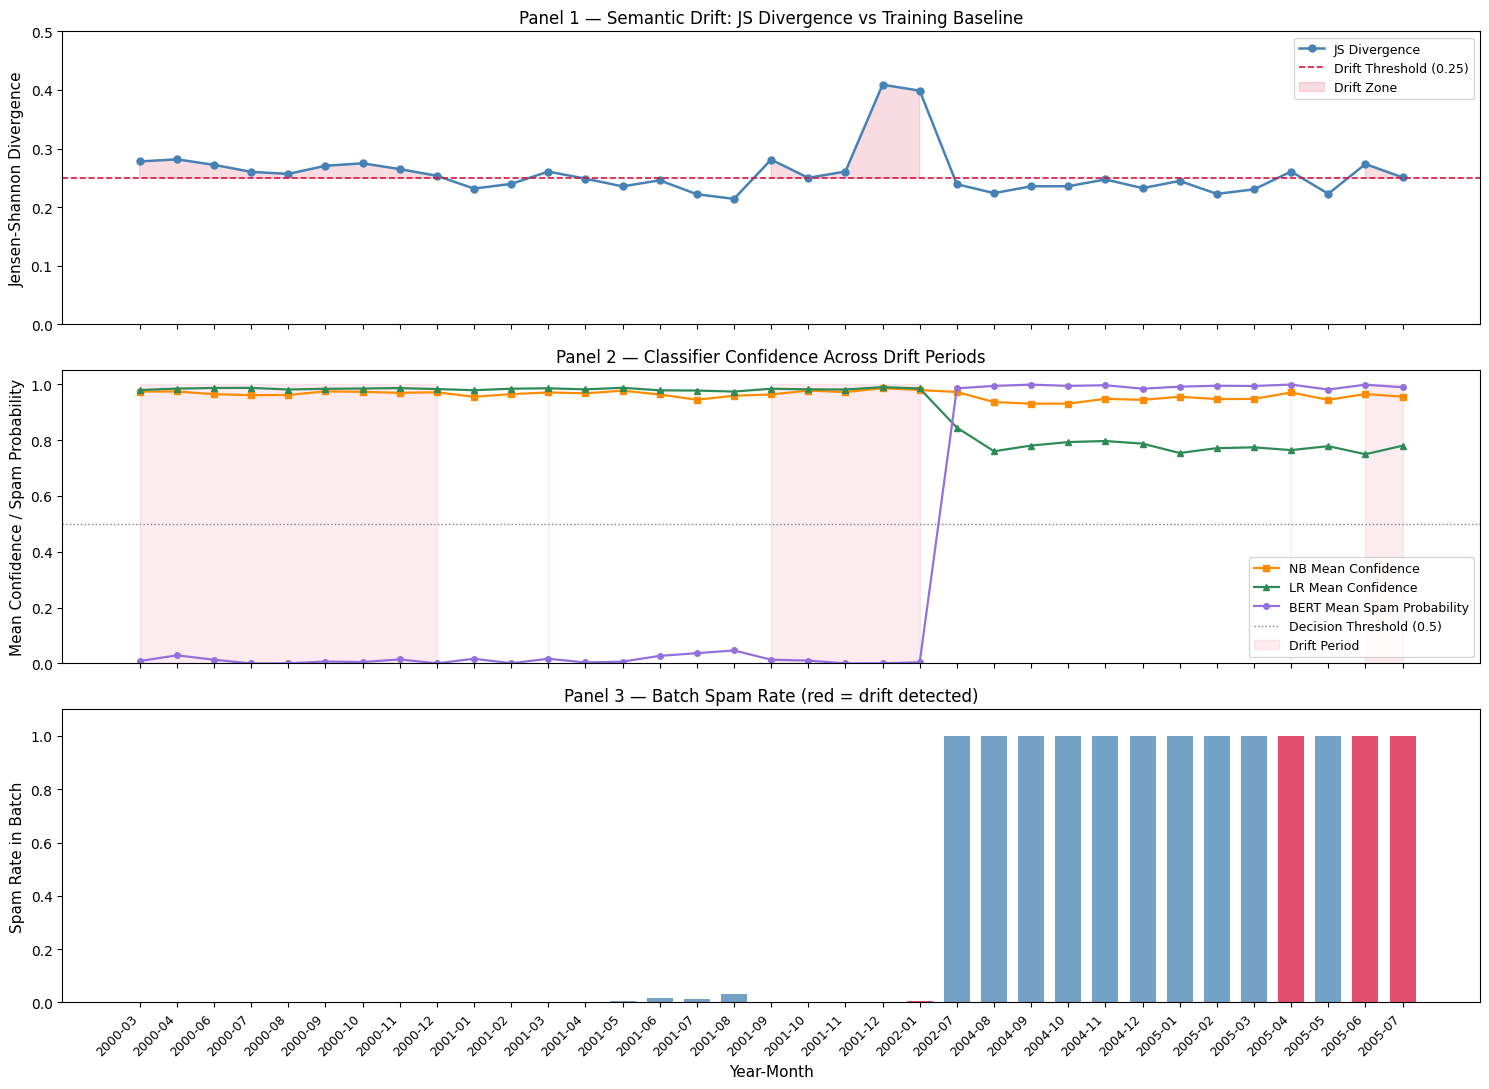

Saved: drift_monitor_extended.png


In [ ]:
# ── Extend drift_df with per-period classifier confidence ─────
for period, batch_df in sorted(monthly_batches.items()):
    batch_texts = batch_df["Message"].tolist()

    # NB confidence on this batch
    nb_probs = nb_model.predict_proba(batch_texts)
    nb_conf  = nb_probs.max(axis=1).mean()

    # LR confidence on this batch
    lr_probs = lr_model.predict_proba(batch_texts)
    lr_conf  = lr_probs.max(axis=1).mean()

    # BERT mean spam probability on this batch
    bert_probs = get_bert_probs_batch(batch_texts, model, tokenizer, device)
    bert_conf  = bert_probs.mean()

    mask = drift_df["period"] == period
    drift_df.loc[mask, "nb_mean_conf"]   = nb_conf
    drift_df.loc[mask, "lr_mean_conf"]   = lr_conf
    drift_df.loc[mask, "bert_mean_prob"] = bert_conf

# ── 3-panel drift visualisation ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
periods = drift_df["period"].astype(str)
x       = range(len(periods))

# ── Panel 1: JS Divergence ────────────────────────────────────
ax1 = axes[0]
ax1.plot(x, drift_df["js_divergence"], marker="o", color="steelblue",
         linewidth=1.8, markersize=5, label="JS Divergence")
ax1.axhline(JS_THRESHOLD, color="crimson", linestyle="--",
            linewidth=1.2, label=f"Drift Threshold ({JS_THRESHOLD})")
ax1.fill_between(x, drift_df["js_divergence"], JS_THRESHOLD,
                 where=drift_df["drift_detected"], alpha=0.15, color="crimson",
                 label="Drift Zone")
ax1.set_ylabel("Jensen-Shannon Divergence", fontsize=11)
ax1.set_title("Panel 1 — Semantic Drift: JS Divergence vs Training Baseline", fontsize=12)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 0.5)

# ── Panel 2: Classifier Confidence Over Time ──────────────────
ax2 = axes[1]
ax2.plot(x, drift_df["nb_mean_conf"],   marker="s", color="darkorange",
         linewidth=1.6, markersize=4, label="NB Mean Confidence")
ax2.plot(x, drift_df["lr_mean_conf"],   marker="^", color="seagreen",
         linewidth=1.6, markersize=4, label="LR Mean Confidence")
ax2.plot(x, drift_df["bert_mean_prob"], marker="o", color="mediumpurple",
         linewidth=1.6, markersize=4, label="BERT Mean Spam Probability")
ax2.axhline(0.5, color="grey", linestyle=":", linewidth=1.0, label="Decision Threshold (0.5)")
ax2.fill_between(x, 0, 1, where=drift_df["drift_detected"].values,
                 alpha=0.08, color="crimson", label="Drift Period")
ax2.set_ylabel("Mean Confidence / Spam Probability", fontsize=11)
ax2.set_title("Panel 2 — Classifier Confidence Across Drift Periods", fontsize=12)
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.05)

# ── Panel 3: Batch Spam Rate ──────────────────────────────────
ax3 = axes[2]
bar_colors = ["crimson" if d else "steelblue" for d in drift_df["drift_detected"]]
ax3.bar(x, drift_df["spam_rate"], color=bar_colors, alpha=0.75, width=0.7)
ax3.set_ylabel("Spam Rate in Batch", fontsize=11)
ax3.set_title("Panel 3 — Batch Spam Rate (red = drift detected)", fontsize=12)
ax3.set_ylim(0, 1.1)

# ── Shared x-axis labels ──────────────────────────────────────
ax3.set_xticks(list(x))
ax3.set_xticklabels(periods, rotation=45, ha="right", fontsize=9)
ax3.set_xlabel("Year-Month", fontsize=11)

plt.tight_layout()
plt.savefig("drift_monitor_extended.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: drift_monitor_extended.png")

In [ ]:
# Build a balanced evaluation set
n_per_class = 200

spam_eval = test_df_reset[test_df_reset["label"] == 1].sample(n_per_class, random_state=42)
ham_eval  = test_df_reset[test_df_reset["label"] == 0].sample(n_per_class, random_state=42)
eval_df   = pd.concat([spam_eval, ham_eval]).sample(frac=1, random_state=42)  # shuffle

# Run the full two-stage pipeline on eval_df
# Then compute:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(eval_df["label"], (final_probs >= 0.5).astype(int)))
print("Base AUC:  ", roc_auc_score(eval_df["label"], base_probs))
print("Hybrid AUC:", roc_auc_score(eval_df["label"], final_probs))
print("Base Brier:  ", brier_score_loss(eval_df["label"], base_probs))
print("Hybrid Brier:", brier_score_loss(eval_df["label"], final_probs))